# Identification of factors

In this notebook, we use supervised information and enrichment tools on previosuly trained DRVI model (immune dataset) to identify biological processes captured by latent factors. We combine multiple complementary strategies:

1. **Cell type annotation** — match factors to known cell types using: 
    * Existing labels
    * Pre-trained classifiers (CellTypist)
    * LLM-based annotators (AnnDictionary, CASSIA)
    * Marker-based enrichment (BlitzGSEA)

3. **Biological Process Annotation** using:
    * **Gene set enrichment analysis (GSEA)** — identify enriched pathways from ranked gene lists (BlitzGSEA,GSEApy Preranked)
    * **Over-representation analysis (ORA)** — test for enriched gene sets using ordered queries (g:Profiler, GSEApy Enrichr)
    * **Regulator activity inference** — infer transcription factor or pathway activity using a statistical framework (decoupler) integrated with prior knowledge 
    * **LLM-based summaries** — gs2txt

**We always advise examination by a biologist and validation against published literature for any identified processes.**

## Intro

This notebook assumes that you have already trained a DRVI model and computed the interpretability scores (via `model.calculate_interpretability_scores`. See the [General training and interpretability pipeline](./general_pipeline.html) tutorial.

The immune dataset is used as a running example, but all code is dataset-agnostic. Configuration variables at the top of each section indicate what to change for your own data.

### Adapting this notebook to your own dataset

To reuse this notebook on a different dataset or DRVI model:

- Update the `0. Load a previously trained model` section.
  - Update `io_dir` to point to your project directory.
  - Make sure the following files exist under `io_dir` with your data (or change the code):
    - `immune_all.h5ad` (or your equivalent full-gene data) in the parent directory.
    - `adata_preprocesses.h5ad` (preprocessed AnnData with HVGs and UMAP)
    - `drvi_model/` (trained DRVI model directory)
    - `embed.h5ad` (latent AnnData with interpretability scores)

Each subsection below is independently runnable after Section 0 — you can skip any tool.


### Config Overview
- The notebook contains multiple independent ways to annotate factors. Each has its own config. Some important configs are:
  - **Section 1.1** For identification based on user annotations, set `annot_col` to the corresponding column in `adata.obs`.
  - **Section 1.2** For identification based on a pre-trained model with CellTypist, choose a model via `ct_model` that matches your tissue / species (e.g. `"Immune_All_Low.pkl"` for PBMC, `"Developing_Mouse_Brain.pkl"` for mouse brain).
  - **Sections 1.3, 1.4, 2.5 (LLM tools — shared Ollama config)** Set `OLLAMA_URL`, `OLLAMA_MODEL`, and `llm_tissue_context` (e.g. `"human immune cells (PBMC / bone marrow)"`). See the *Ollama setup guide* block just before Section 1 for details on running a local Ollama server.
  - **Section 1.4** For CASSIA, set `llm_species` (e.g. `"Human"`, `"Mouse"`).
  - **Section 2.1** For BlitzGSEA, set:
    - `process_blitzgsea_db` (e.g. `"GO_Biological_Process_2023"`, `"Reactome_2022"`) — for biological process enrichment.
    - `celltype_blitzgsea_dbs` (list, e.g. `["CellMarker_2024", "PanglaoDB_Augmented_2021"]`) — for cell-type enrichment.
    - `fdr_threshold` to keep significant results.
  - **Section 2.2** For GSEApy, set:
    - `gseapy_db` (e.g. `"GO_Biological_Process_2023"`) — used by both the    prerank GSEA and Enrichr ORA subsections.
  - **Section 2.3** For g:Profiler, set:
    - `organism` (e.g. `"hsapiens"`, `"mmusculus"`).
    - `gp_source` to the GO / pathway collections you care about (e.g. `["GO:BP"]`, `["REAC"]`).
    - `pval_threshold` to keep significant results.
  - **Section 2.4** For decoupler, set:
    - `dc_geneset` (e.g. `"collectri"`, `"dorothea"`, `"progeny"` or another resource name).
    - `dc_organism` to match your species (e.g. `"human"`, `"mouse"`).
    - `fdr_threshold` to keep significant results.
  - **Section 2.5** For gs2txt, set `llm_species` in `GeneSetAnnotator` (`"human"` or `"mouse"`) and `enrichment_method` (e.g. `"pathway"`).

## Requirements

This notebook requires the following python packages:
```
celltypist
blitzgsea
gseapy
gprofiler-official
decoupler
anndict        # section 1.3 (LLM)
CASSIA         # section 1.4 (LLM)
gs2txt         # section 2.5 (LLM)
```

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Install

If you try DRVI on colab, the next cell will install dependencies. Please remove this part if your environment is already set up.

In [1]:
import sys
import subprocess

branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install", "drvi[tutorials]"])
elif IN_COLAB and branch != "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "git+https://github.com/theislab/drvi.git#egg=drvi[tutorials]"])

if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "celltypist", "blitzgsea", "gseapy",
                           "gprofiler-official", "decoupler",
                           "anndict", "CASSIA", "gs2txt"])

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import scvi
import drvi
from pathlib import Path
from drvi.model import DRVI
from drvi.utils.misc import hvg_batch

In [ ]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.1
Last run with DRVI version: 0.2.4


In [ ]:
# Plot defaults
%matplotlib inline
sc.set_figure_params(dpi=100, frameon=False, figsize=(3, 3))
plt.rcParams["figure.dpi"] = 100

## 0. Setting up 

### Config

In [4]:
# Set input/output directory. Update accordingly.
io_dir = Path("/home/icb/clara.sanchez/data/drvi_immune_128").resolve()
print(f"Using directory: {io_dir}")

Using directory: /ictstr01/groups/ml01/workspace/clara.sanchez/data/drvi_immune_128


### Load Data

In [5]:
raw_data_path = io_dir / "immune_all.h5ad"
adata_full = sc.read_h5ad(raw_data_path)
adata_full

AnnData object with n_obs × n_vars = 33506 × 12303
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue'
    layers: 'counts'

In [6]:
# AnnData which DRVI was trained on (HVG selected)
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")
adata

AnnData object with n_obs × n_vars = 32484 × 2000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue'
    uns: 'batch_colors', 'final_annotation_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

### Load DRVI outputs

In [7]:
model_path = io_dir / "drvi_model"
embed_path = io_dir / "embed.h5ad"

model = DRVI.load(model_path, adata)
embed = sc.read_h5ad(embed_path)

INFO     File /ictstr01/groups/ml01/workspace/clara.sanchez/data/drvi_immune_128/drvi_model/model.pt already       
         downloaded                                                                                                
INFO     DRVI: The model is trained with DRVI version 0.2.2.                                                       
INFO     DRVI: Updaging data setup config ...                                                                      
INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.4.                                  
INFO     DRVI: Loading model from DRVI version 0.2.2.                                                              
INFO     DRVI: Done updating model args. Loading in 0.2.4.                                                         
INFO     DRVI: The model has been initialized                                                                      


### Ollama setup guide (For LLM-based sections)

**Skip this section if you don't want to use LLM-based annotation tools.**

Ollama is an open-source tool that lets you run LLMs (Llama 3, Qwen, ...) locally or on a cluster. 

**0. Install** (one-time, on a login node — most clusters disallow Docker, so use Apptainer):
```bash
mkdir -p ~/containers
apptainer pull ~/containers/ollama.sif docker://ollama/ollama:latest
```

**1. Start a GPU job** via your scheduler (e.g. Slurm).

**2. Launch the container** (replace bind paths with your cluster storage):
```bash
apptainer shell --nv --bind /localscratch --bind /lustre/groups/ml01/ ~/containers/ollama.sif
```

**3. Start the server** on a custom port to avoid conflicts:
```bash
OLLAMA_HOST=0.0.0.0:8979 ollama serve &
```

**4. Pull a model**:
```bash
export OLLAMA_HOST=127.0.0.1:8979
ollama pull qwen3.5
```

Update `OLLAMA_URL` and `OLLAMA_MODEL` below to match.

In [ ]:
import requests

In [ ]:
# OLLAMA CONFIGURATION (shared by AnnDictionary, CASSIA, gs2txt)
OLLAMA_URL   = "http://supergpu23.scidom.de:8978" #replace with your node and port if different
OLLAMA_MODEL = "qwen2.5:latest"

llm_top_n_genes = 100
llm_tissue_context = "human immune cells (PBMC / bone marrow)"



In [ ]:
# Test connection
r = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
print("Available models:", [m["name"] for m in r.json().get("models", [])])

Available models: ['qwen3.5:latest', 'qwen2.5:latest']


## 1. Identifying Cell-Type Specific Processes

Some latent factors capture cell-type identity. We identify them using:

- **Known annotations**: We measure alignment between factors and annotated cell types via Scaled Mutual Information (SMI). We note that DRVI dimensions may be more fine grained than these annotations, resemble a process covering multiple cell types, or showing general shared processes. However, this approach allows identification of large proportion of processes. For this we need some supervised info such as:
  - **User annotations** (Section 1.1):  Where user has annotated its data.
  - **Annotation tools** (Section 1.2, 1.3 and 1.4):  User can also use pre-trained models such as CellTypist or Foundational Models to classify cells.
- **Enrichment**: Using GSEA/ORA methods with Cell Type databases. This is described in the **Biological Process Identification** section using BlitzGSEA.

### 1.1 Identification based on user annotations

If your dataset has existing cell type annotations, Scaled Mutual Information (SMI) measures how well each latent factor aligns with each annotated category. SMI is normalized to [0, 1], where 1 indicates perfect correspondence between a factor and a cell type.

**Skip this section if your dataset does not have cell type annotations.**

####  Imports

In [67]:
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

#### Config

In this dataset annotations are stored in `adata.obs["final_annotation"]`.


In [68]:
# Column in adata.obs containing cell type labels. Set to None if not available.
annot_col = "final_annotation" 

# minimum SMI to consider a factor associated with a cell type. Adjust as needed.
smi_threshold = 0.7

#### Visualize with a Heatmap

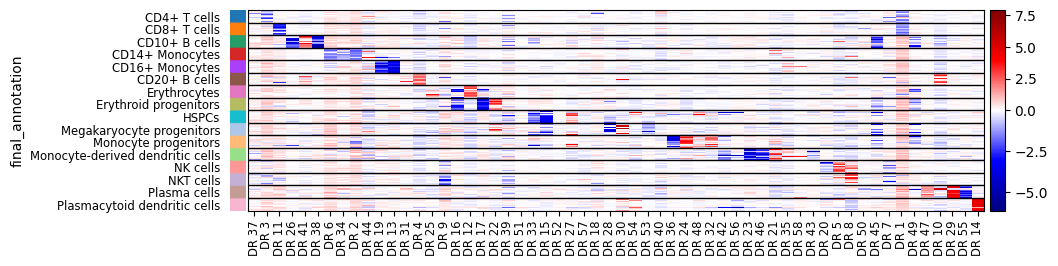

In [69]:
drvi.utils.pl.plot_latent_dims_in_heatmap(embed, annot_col, title_col="title", sort_by_categorical=True)

We observe very good one-to-one relationship between some factors and cell types. Let's identify them

#### Prepare data

We prepare a matrix where columns are positive and negative nonvanished latent factors and rows are cells

In [70]:
embed_pos = embed[:, ~embed.var['vanished_positive_direction']].copy()
embed_neg = embed[:, ~embed.var['vanished_negative_direction']].copy()
embed_pos.var.index = embed_pos.var['title'] + '+'
embed_neg.var.index = embed_neg.var['title'] + '-'
embed_pos.X = embed_pos.X.clip(min=0)
embed_neg.X = -embed_neg.X.clip(max=0)
embed_directional_df = pd.concat([embed_pos.to_df(), embed_neg.to_df()], axis=1).loc[embed.obs.index]
embed_directional_df[:3]

title,DR 32+,DR 28+,DR 2+,DR 6+,DR 35+,DR 9+,DR 44+,DR 27+,DR 24+,DR 54+,...,DR 26-,DR 56-,DR 50-,DR 20-,DR 3-,DR 48-,DR 10-,DR 41-,DR 43-,DR 45-
index,,,,,,,,,,,,,,,,,,,,,
CTCCTAGGTCTCACCT-1-Oetjen_U,0.000000,0.011543,0.438667,0.497775,0.0,0.722904,0.000000,0.000000,0.000000,0.000000,...,-0.0,-0.000000,0.421552,-0.0000,0.064120,-0.0,0.666332,0.270653,0.029144,-0.000000
ACACAGTAGGTGCATG-1-10X,0.000000,0.228838,0.000000,0.000000,0.0,0.000000,0.609732,0.000000,0.000000,0.002237,...,-0.0,0.002937,1.077603,-0.0000,0.530179,-0.0,0.244196,0.223278,-0.000000,0.037434
CGACTTCGTAGCGTCC-1-Oetjen_A,3.442611,0.447561,0.804222,0.902006,0.0,0.906220,0.000000,1.766781,0.047304,0.000000,...,-0.0,-0.000000,-0.000000,0.2617,-0.000000,-0.0,0.323722,-0.000000,-0.000000,0.367555


#### Calculation of Scaled Mutual Information

`DiscreteDisentanglementBenchmark` computes pairwise similarity between latent factors and supervised targets.

In [71]:
# Compute SMI between each factor-direction (+/-) and each annotated cell type.
benchmark = DiscreteDisentanglementBenchmark(
    embed_directional_df.values,
    dim_titles=embed_directional_df.columns,
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc"],
    aggregation_methods=[],
)
benchmark.evaluate()
smi_similarity = benchmark.get_results_details()["SMI-disc"]
smi_similarity.index.name = "title"

In [72]:
print(f"SMI matrix shape: {smi_similarity.shape} (factor-directions x cell types)")
smi_similarity[:3]

SMI matrix shape: (116, 16) (factor-directions x cell types)


,CD4+ T cells,CD8+ T cells,CD10+ B cells,CD14+ Monocytes,CD16+ Monocytes,CD20+ B cells,Erythrocytes,Erythroid progenitors,HSPCs,Megakaryocyte progenitors,Monocyte progenitors,Monocyte-derived dendritic cells,NK cells,NKT cells,Plasma cells,Plasmacytoid dendritic cells
title,,,,,,,,,,,,,,,,
DR 32+,0.008323,0.003136,0.001647,0.002511,0.002876,0.004100,0.002586,0.002306,0.068147,0.016850,0.510319,0.002558,0.003417,0.003763,0.001785,0.002289
DR 28+,0.008948,0.002599,0.011678,0.000854,0.001998,0.001302,0.087773,0.019079,0.026222,0.013697,0.051273,0.015935,0.011560,0.002223,0.073702,0.004274
DR 2+,0.105549,0.028129,0.032700,0.605448,0.020785,0.094714,0.039492,0.029894,0.035749,0.023460,0.057278,0.141636,0.062813,0.055139,0.020585,0.036191


In [73]:
# Reshape the SMI matrix from wide to long format, then keep only pairs above the threshold.
smi_top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars="title", value_vars=smi_similarity.columns)
    .query("value >= @smi_threshold")
    .reset_index(drop=True)
    .sort_values("value", ascending=False)
)
print(f"Factor–cell type pairs with SMI >= {smi_threshold}: {len(smi_top_matches)}")
smi_top_matches

Factor–cell type pairs with SMI >= 0.7: 15


,title,variable,value
14,DR 14+,Plasmacytoid dendritic cells,0.935087
5,DR 13-,CD16+ Monocytes,0.912577
12,DR 29+,Plasma cells,0.911211
6,DR 4+,CD20+ B cells,0.903194
13,DR 55-,Plasma cells,0.839457
3,DR 6-,CD14+ Monocytes,0.798203
11,DR 47+,Plasma cells,0.792203
2,DR 2-,CD14+ Monocytes,0.789630
9,DR 46-,Monocyte-derived dendritic cells,0.789474
10,DR 23-,Monocyte-derived dendritic cells,0.778643


#### Helper function for relationship Visualization

In [74]:
def plot_packed_network(df, title_col="title", var_col="variable", val_col="value", figsize=(14, 10)):
    """Visualizes factor–cell type associations as a network with edge weights."""
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)

    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = 3
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=figsize)
    titles = set(df[title_col])
    weights = [d[val_col] for u, v, d in G.edges(data=True)]
    nx.draw(
        G, pos,
        with_labels=True, font_size=8, font_weight="bold", node_size=600,
        node_color=["#A0CBE2" if n in titles else "#FF9E9E" for n in G.nodes()],
        width=[w * 4 for w in weights],
        edge_color=weights, edge_cmap=plt.cm.Oranges, alpha=0.6,
    )
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.axis("off")
    plt.show()

#### Plot Packed Visualization

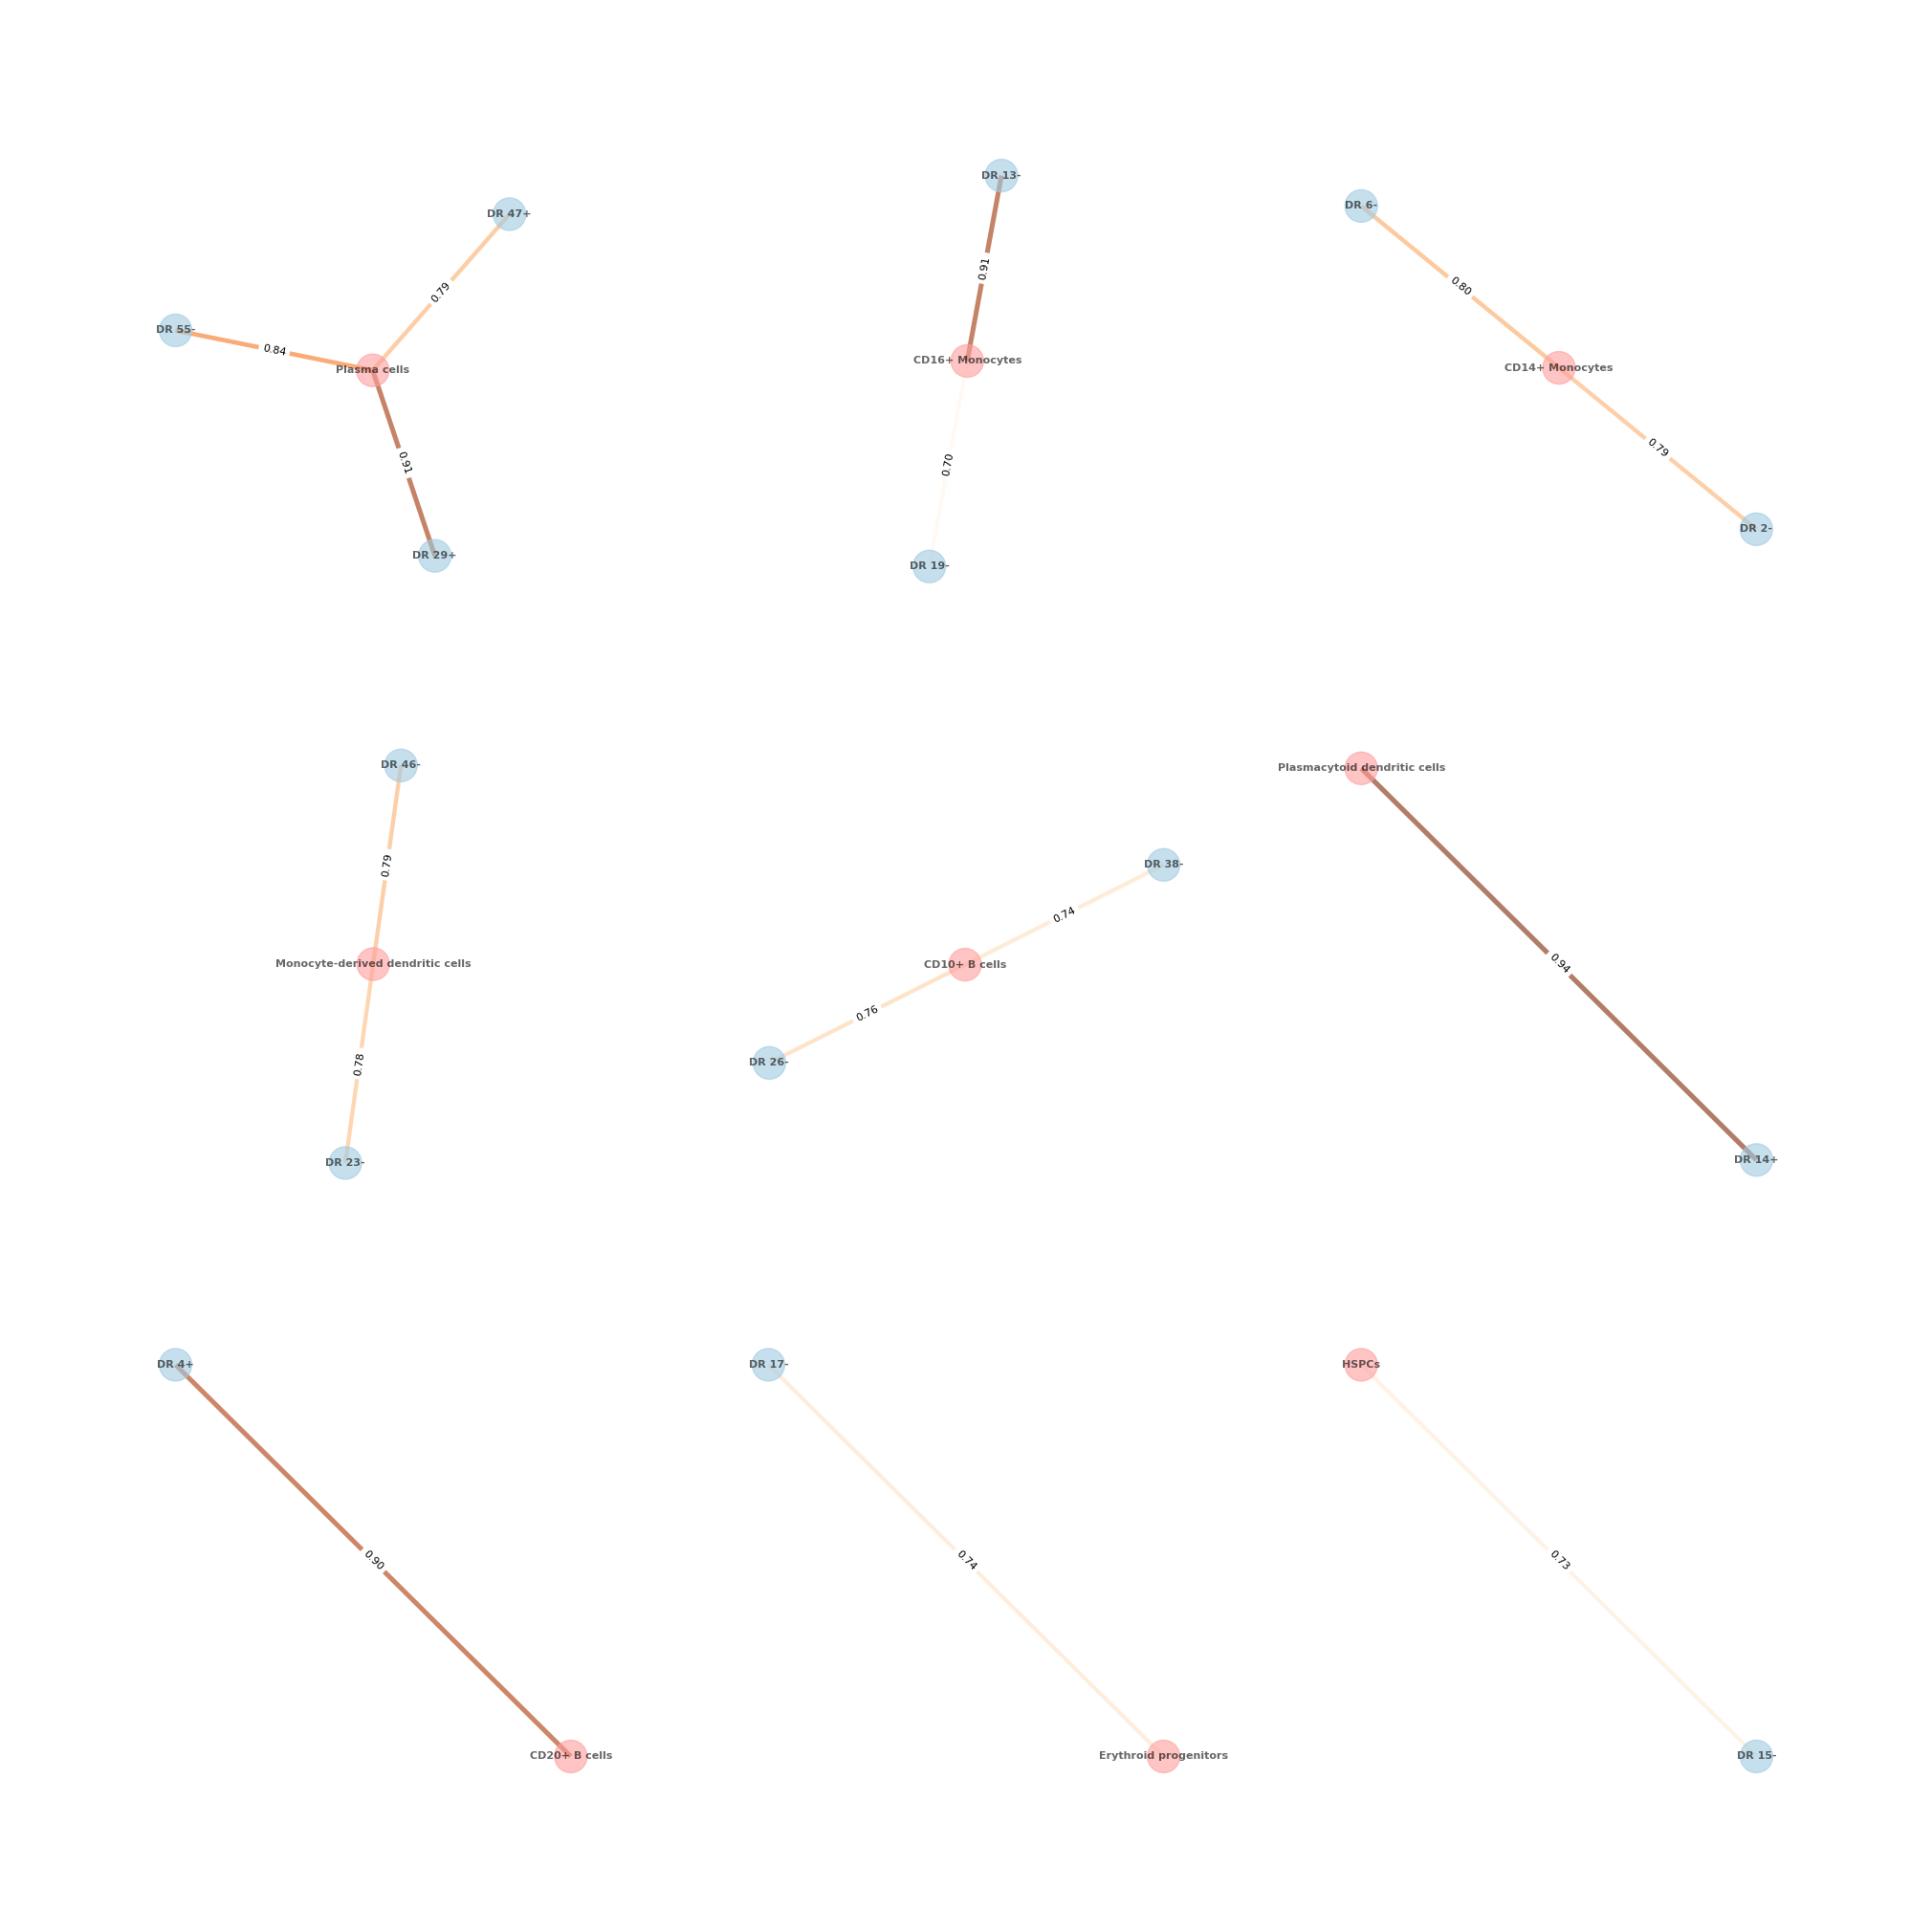

In [75]:
plot_packed_network(smi_top_matches, figsize=(20, 20))

#### Store summary in var

In [76]:
first_match = smi_top_matches.drop_duplicates(subset=['title'])
first_match['direction'] = first_match['title'].str[-1:]
first_match['title'] = first_match['title'].str[:-1]
first_match_pos = first_match.query("direction == '+'")
first_match_neg = first_match.query("direction == '-'")
embed.var.set_index("title", drop=False, inplace=True)
embed.var[f'positive_direction_match_with_user_annotations'] = None
embed.var[f'negative_direction_match_with_user_annotations'] = None
embed.var[f'positive_direction_match_with_user_annotations'][first_match_pos['title']] = first_match_pos['variable']
embed.var[f'negative_direction_match_with_user_annotations'][first_match_neg['title']] = first_match_neg['variable']
embed.var.index = embed.var["original_dim_id"].astype(int).astype(str)
embed.var.index.name = None

(
    embed.var[f'positive_direction_match_with_user_annotations'].unique(),
    embed.var[f'negative_direction_match_with_user_annotations'].unique(),
)

(array([None, 'Plasma cells', 'CD20+ B cells',
        'Plasmacytoid dendritic cells'], dtype=object),
 array([None, 'CD14+ Monocytes', 'CD16+ Monocytes',
        'Erythroid progenitors', 'CD10+ B cells',
        'Monocyte-derived dendritic cells', 'HSPCs', 'Plasma cells'],
       dtype=object))

#### Store results in uns

In [77]:
embed.uns['best_smi_matching_user_annotations_results'] = smi_top_matches

#### Interpretation

When manual annotations exist, SMI provides the highest-confidence anchor in the pipeline: it shows which latent factors encode the cell types already labelled in the dataset. For the immune atlas, 15 factor-directions exceed SMI 0.7. Strong one-to-one mappings include:

- **DR 14+ → Plasmacytoid dendritic cells** (SMI 0.94)
- **DR 13− → CD16+ Monocytes** (0.91)
- **DR 29+ → Plasma cells** (0.91)
- **DR 4+ → CD20+ B cells** (0.90)
- **DR 6− → CD14+ Monocytes** (0.80)

The matched factors then serve two roles for the rest of the notebook: they confirm the model has learned biologically meaningful axes, and they provide a reference set against which the other annotation tools can be sanity-checked — any tool worth using should return relevant terms for these specific factor-directions.

Most factors will not match a user annotation, and that is expected. Annotations are typically coarse (lineage-level), while latent factors can also encode much finer subtypes, developmental stages, and biological processes shared across cell types. The remaining subsections of this notebook exist to characterise those unmatched factors. When no manual annotations are available, this section is skipped and the alternative cell-type annotation tools below take its place as the starting point.

### 1.2 Identification based on pre-trained model

[CellTypist](https://www.celltypist.org/) is a logistic-regression classifier trained on large annotated atlases. We compute SMI between CellTypist probabilities (cells × cell types) and DRVI factor activities (cells × factors) to link factors to CellTypist cell types.

**Note 1: Users can skip this if they already have good annotations.**

**Note 2: Only the annotation part is different from the previous section and everything is duplicate from `prepare data` section.**

#### Imports

In [78]:
import celltypist
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

#### Config

In [79]:
# Minimum SMI score between factor and cell-type probability profiles to consider a factor as associated with a cell type. Adjust as needed.
smi_threshold = 0.7

# We use "celltypist_majority" from cell typist outputs
annot_col = "celltypist_majority"

In [80]:
# CellTypist Model

# Run celltypist.models.models_description() to see all available models. 
# # Run print(ct_model.cell_types) to see available cell types
# Choose one matching your tissue. 
ct_model = "Immune_All_Low.pkl"  # e.g. "Developing_Mouse_Brain.pkl" 
celltypist.models.download_models(force_update=False, model=ct_model)

ct_model = celltypist.models.Model.load(model=ct_model)


2026-04-15 16:04:37 | [INFO] 📂 Storing models in /home/icb/clara.sanchez/.celltypist/data/models
2026-04-15 16:04:37 | [INFO] 💾 Total models to download: 1
2026-04-15 16:04:37 | [INFO] ⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)


#### CellTypist Annotation

Each cell receives a predicted label via logistic regression based on its transcriptomic profile. `majority_voting=True` refines labels by taking the most frequent label within a cell's kNN neighborhood (reduces noise). The resulting per-cell labels are stored in adata.obs.

In [81]:
# CellTypist expects normalized, log1p data; use the full gene set.
adata_full.X = adata_full.layers['counts'].copy()
sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)

predictions = celltypist.annotate(adata_full, model=ct_model, majority_voting=True)

2026-04-15 16:04:39 | [INFO] 🔬 Input data has 33506 cells and 12303 genes
2026-04-15 16:04:39 | [INFO] 🔗 Matching reference genes in the model
2026-04-15 16:04:40 | [INFO] 🧬 4296 features used for prediction
2026-04-15 16:04:40 | [INFO] ⚖️ Scaling input data
2026-04-15 16:04:41 | [INFO] 🖋️ Predicting labels
2026-04-15 16:04:42 | [INFO] ✅ Prediction done!
2026-04-15 16:04:42 | [INFO] 👀 Can not detect a neighborhood graph, will construct one before the over-clustering
2026-04-15 16:05:50 | [INFO] ⛓️ Over-clustering input data with resolution set to 15
2026-04-15 16:05:51 | [INFO] 🗳️ Majority voting the predictions
2026-04-15 16:05:51 | [INFO] ✅ Majority voting done!


In [82]:
embed.obs["celltypist_labels"] = predictions.predicted_labels["predicted_labels"].loc[embed.obs.index]
embed.obs["celltypist_majority"] = predictions.predicted_labels["majority_voting"].loc[embed.obs.index]
embed.obsm["celltypist_probs"] = predictions.probability_matrix[embed.obs["celltypist_majority"].cat.categories].loc[embed.obs.index]

#### Visualize with a Heatmap

... storing 'positive_direction_match_with_user_annotations' as categorical
... storing 'negative_direction_match_with_user_annotations' as categorical


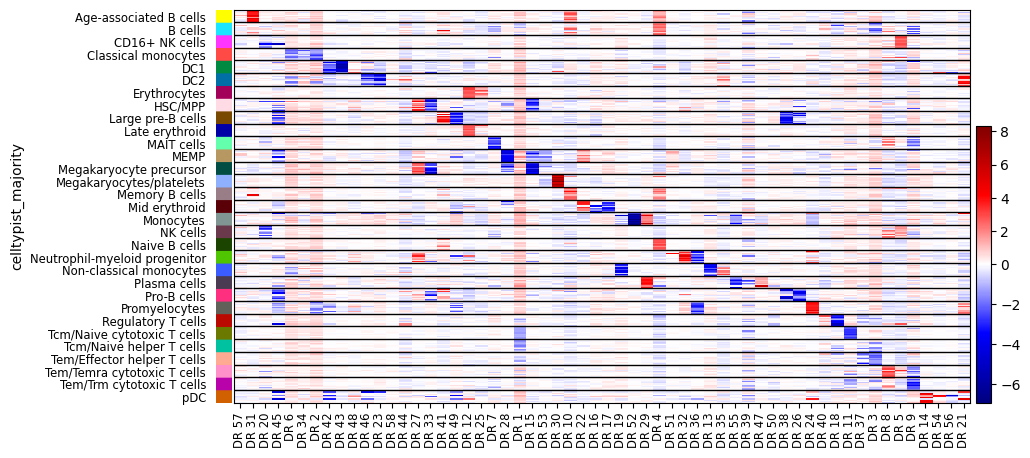

In [83]:
drvi.utils.pl.plot_latent_dims_in_heatmap(
    embed, 
    annot_col, 
    title_col="title", 
    sort_by_categorical=True,
)

We observe very good one-to-one relationship between some factors and cell types. Let's identify them

#### Prepare data

We prepare a matrix where columns are positive and negative nonvanished latent factors and rows are cells

In [84]:
embed_pos = embed[:, ~embed.var['vanished_positive_direction']].copy()
embed_neg = embed[:, ~embed.var['vanished_negative_direction']].copy()
embed_pos.var.index = embed_pos.var['title'] + '+'
embed_neg.var.index = embed_neg.var['title'] + '-'
embed_pos.X = embed_pos.X.clip(min=0)
embed_neg.X = -embed_neg.X.clip(max=0)
embed_directional_df = pd.concat([embed_pos.to_df(), embed_neg.to_df()], axis=1).loc[embed.obs.index]
embed_directional_df[:3]

title,DR 32+,DR 28+,DR 2+,DR 6+,DR 35+,DR 9+,DR 44+,DR 27+,DR 24+,DR 54+,...,DR 26-,DR 56-,DR 50-,DR 20-,DR 3-,DR 48-,DR 10-,DR 41-,DR 43-,DR 45-
index,,,,,,,,,,,,,,,,,,,,,
CTCCTAGGTCTCACCT-1-Oetjen_U,0.000000,0.011543,0.438667,0.497775,0.0,0.722904,0.000000,0.000000,0.000000,0.000000,...,-0.0,-0.000000,0.421552,-0.0000,0.064120,-0.0,0.666332,0.270653,0.029144,-0.000000
ACACAGTAGGTGCATG-1-10X,0.000000,0.228838,0.000000,0.000000,0.0,0.000000,0.609732,0.000000,0.000000,0.002237,...,-0.0,0.002937,1.077603,-0.0000,0.530179,-0.0,0.244196,0.223278,-0.000000,0.037434
CGACTTCGTAGCGTCC-1-Oetjen_A,3.442611,0.447561,0.804222,0.902006,0.0,0.906220,0.000000,1.766781,0.047304,0.000000,...,-0.0,-0.000000,-0.000000,0.2617,-0.000000,-0.0,0.323722,-0.000000,-0.000000,0.367555


#### Calculation of Scaled Mutual Information

We use `DiscreteDisentanglementBenchmark` class that we use for evaluation of models. This class calculated pairwise similarity function between latent factors and supervised targets.

In [85]:
# Compute SMI between each factor-direction (+/-) and each cell type probability.
benchmark = DiscreteDisentanglementBenchmark(
    embed_directional_df.values,
    dim_titles=embed_directional_df.columns,
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc"],
    aggregation_methods=[],
)
benchmark.evaluate()
smi_similarity = benchmark.get_results_details()["SMI-disc"]
smi_similarity.index.name = "title"

In [86]:
print(f"SMI matrix shape: {smi_similarity.shape} (factor-directions x cell types)")
smi_similarity[:3]

SMI matrix shape: (116, 31) (factor-directions x cell types)


,Age-associated B cells,B cells,CD16+ NK cells,Classical monocytes,DC1,DC2,Erythrocytes,HSC/MPP,Large pre-B cells,Late erythroid,...,Plasma cells,Pro-B cells,Promyelocytes,Regulatory T cells,Tcm/Naive cytotoxic T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,pDC
title,,,,,,,,,,,,,,,,,,,,,
DR 32+,0.001874,0.001790,0.003361,0.004894,0.001725,0.002522,0.002262,0.100747,0.002249,0.002010,...,0.001785,0.002764,0.380309,0.002374,0.003013,0.007614,0.003063,0.002948,0.003069,0.002388
DR 28+,0.033482,0.105369,0.011222,0.000628,0.072984,0.007781,0.029972,0.029930,0.040540,0.060673,...,0.084662,0.014199,0.037608,0.001462,0.006685,0.005972,0.014212,0.001954,0.011858,0.008704
DR 2+,0.058664,0.047012,0.052694,0.569099,0.200749,0.154680,0.033110,0.022918,0.036825,0.029657,...,0.025164,0.026235,0.150836,0.071103,0.035493,0.088142,0.029678,0.033459,0.033999,0.017796


In [87]:
# Reshape the SMI matrix from wide to long format, then keep only pairs above the threshold.
smi_top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars="title", value_vars=smi_similarity.columns)
    .query("value >= @smi_threshold")
    .reset_index(drop=True)
    .sort_values("value", ascending=False)
)
print(f"Factor–cell type pairs with SMI >= {smi_threshold}: {len(smi_top_matches)}")
smi_top_matches

Factor–cell type pairs with SMI >= 0.7: 34


,title,variable,value
19,DR 52-,Monocytes,0.985982
26,DR 29+,Plasma cells,0.963268
4,DR 43-,DC1,0.945736
17,DR 17-,Mid erythroid,0.930684
14,DR 30+,Megakaryocytes/platelets,0.917412
24,DR 13-,Non-classical monocytes,0.914140
27,DR 55-,Plasma cells,0.888262
16,DR 10+,Memory B cells,0.864522
18,DR 29+,Monocytes,0.855189
12,DR 28-,MEMP,0.851137


#### Helper function for relationship Visualization

In [88]:
def plot_packed_network(df, title_col="title", var_col="variable", val_col="value", figsize=(14, 10)):
    """Visualizes factor–cell type associations as a network with edge weights."""
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)

    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = 3
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=figsize)
    titles = set(df[title_col])
    weights = [d[val_col] for u, v, d in G.edges(data=True)]
    nx.draw(
        G, pos,
        with_labels=True, font_size=8, font_weight="bold", node_size=600,
        node_color=["#A0CBE2" if n in titles else "#FF9E9E" for n in G.nodes()],
        width=[w * 4 for w in weights],
        edge_color=weights, edge_cmap=plt.cm.Oranges, alpha=0.6,
    )
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.axis("off")
    plt.show()

#### Plot Packed Visualization

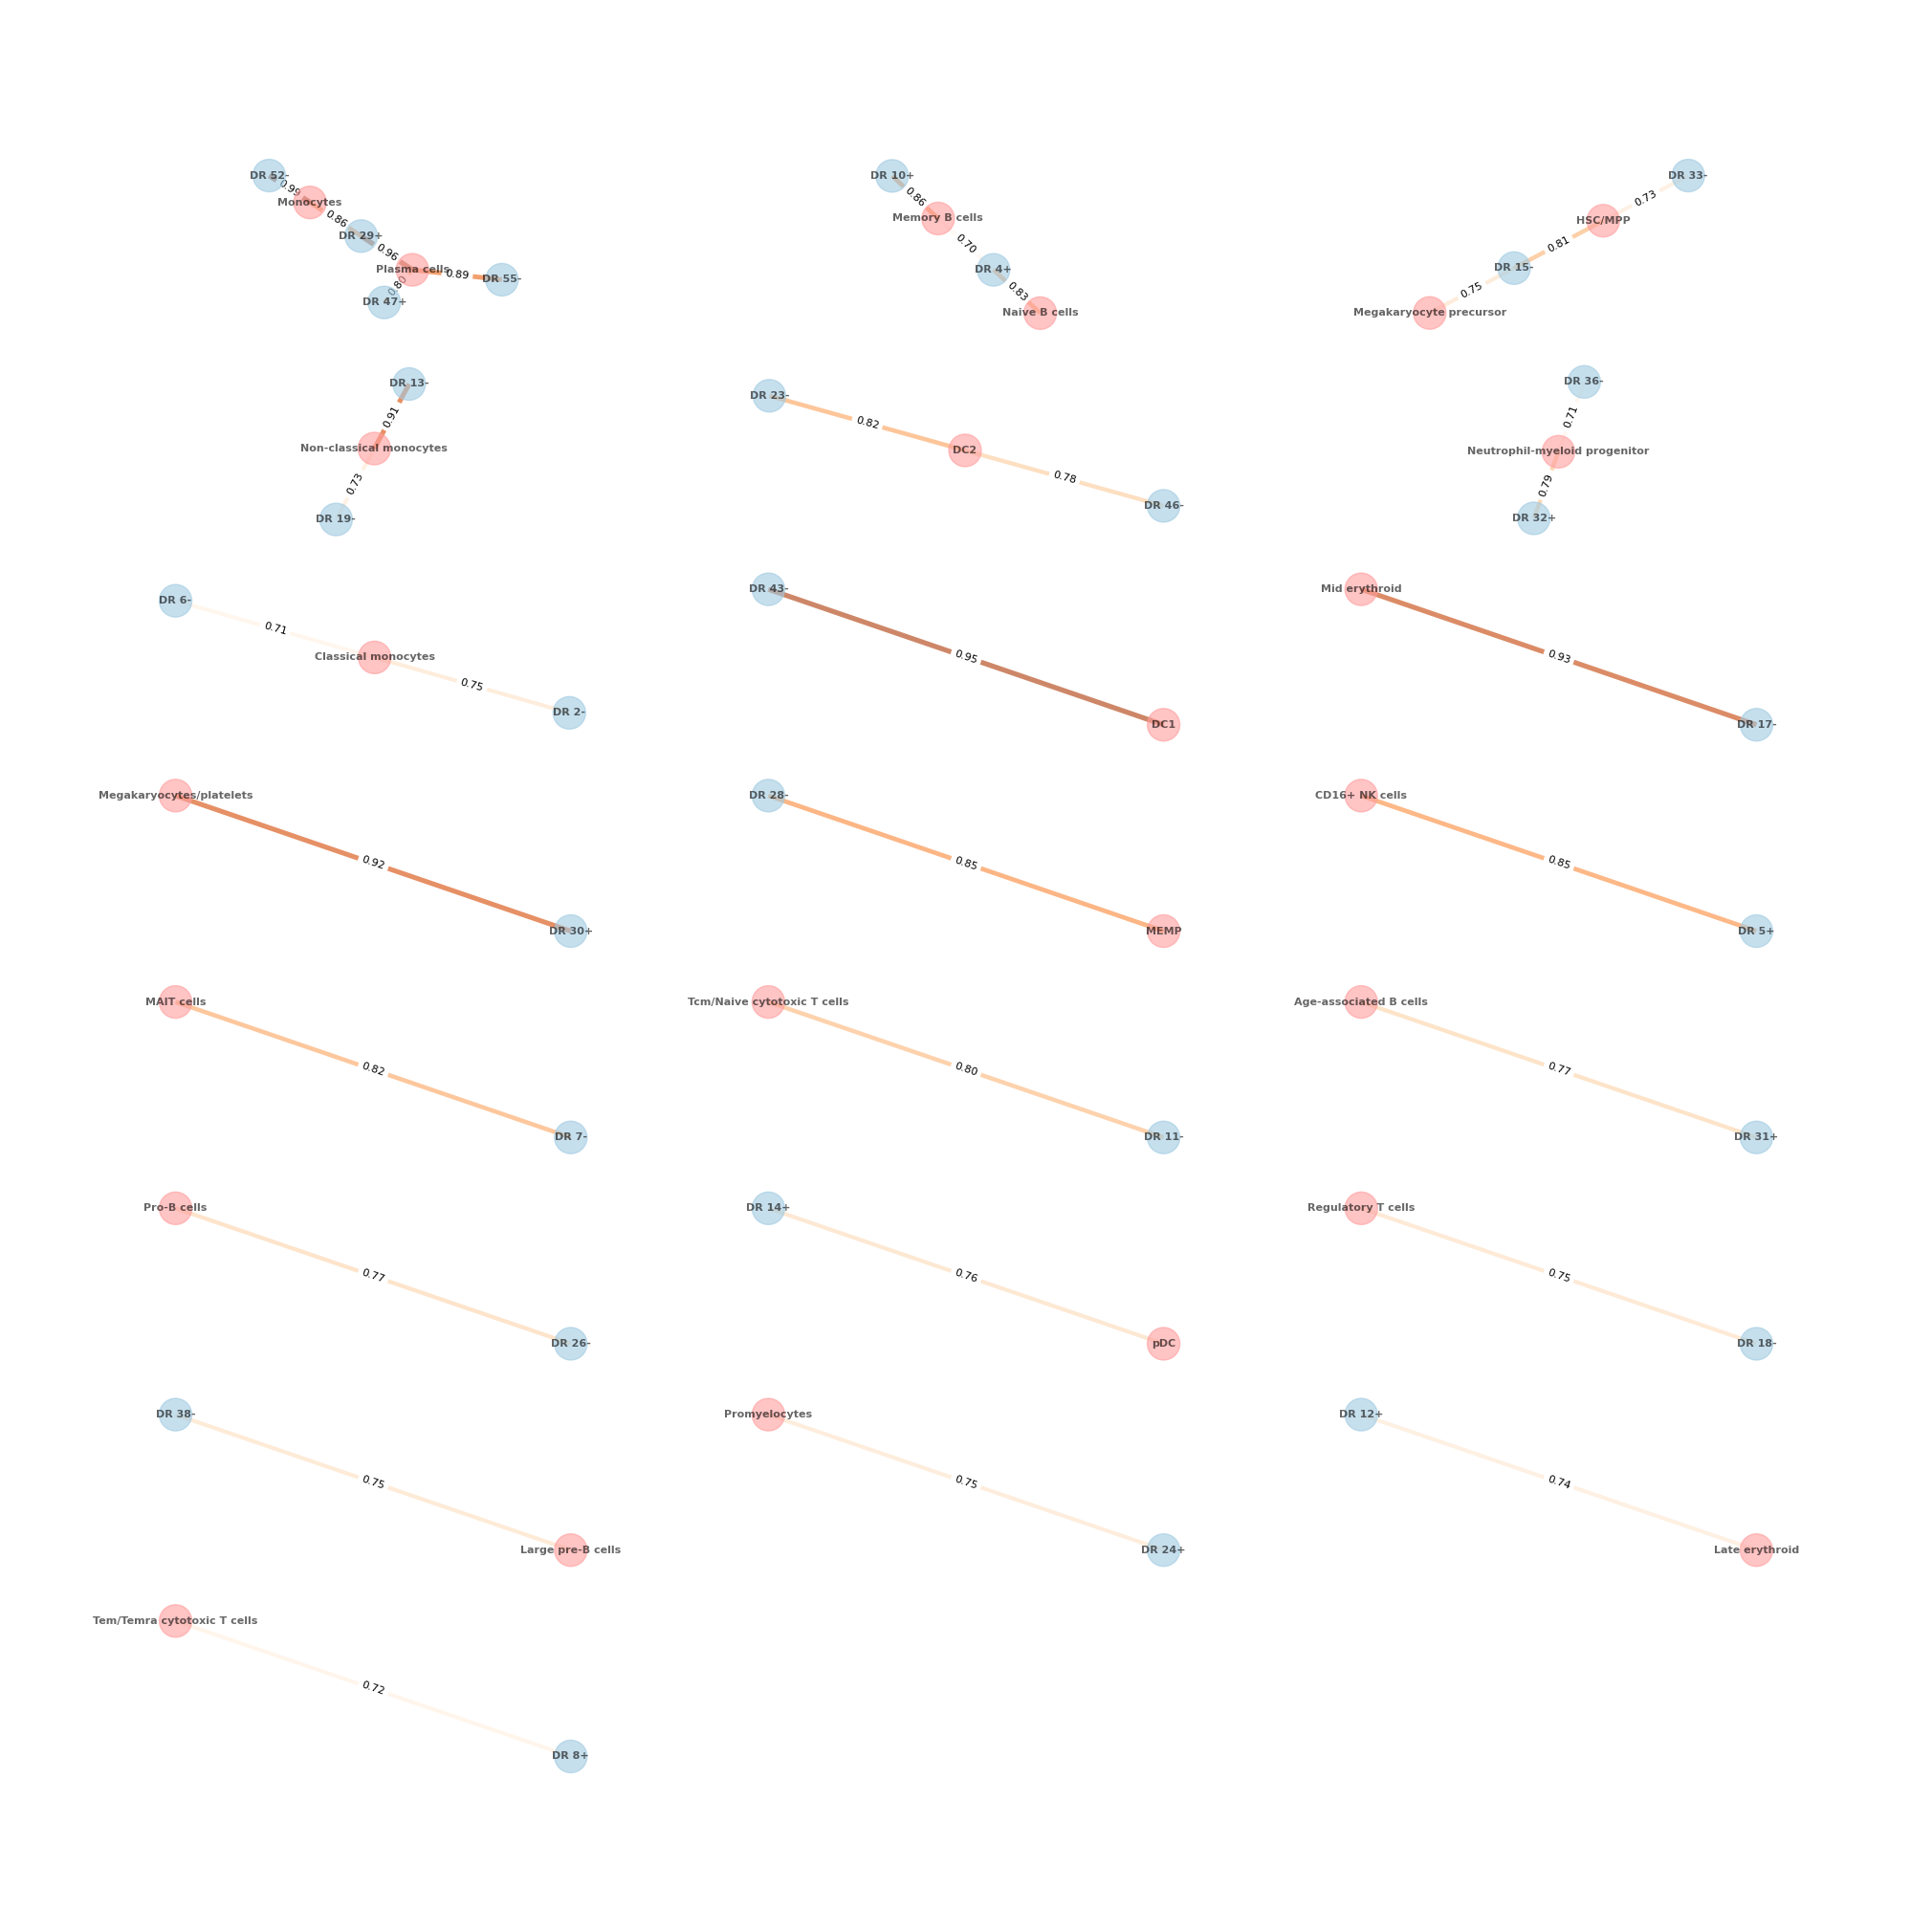

In [89]:
plot_packed_network(smi_top_matches, figsize=(20, 20))

#### Store summary in var

In [90]:
first_match = smi_top_matches.drop_duplicates(subset=['title'])
first_match['direction'] = first_match['title'].str[-1:]
first_match['title'] = first_match['title'].str[:-1]
first_match_pos = first_match.query("direction == '+'")
first_match_neg = first_match.query("direction == '-'")
embed.var.set_index("title", drop=False, inplace=True)
embed.var[f'positive_direction_match_with_celltypist'] = None
embed.var[f'negative_direction_match_with_celltypist'] = None
embed.var[f'positive_direction_match_with_celltypist'][first_match_pos['title']] = first_match_pos['variable']
embed.var[f'negative_direction_match_with_celltypist'][first_match_neg['title']] = first_match_neg['variable']
embed.var.index = embed.var["original_dim_id"].astype(int).astype(str)
embed.var.index.name = None

(
    embed.var[f'positive_direction_match_with_celltypist'].unique(),
    embed.var[f'negative_direction_match_with_celltypist'].unique(),
)

(array(['Neutrophil-myeloid progenitor', None, 'Promyelocytes',
        'Age-associated B cells', 'Late erythroid',
        'Megakaryocytes/platelets', 'Plasma cells', 'Naive B cells',
        'Tem/Temra cytotoxic T cells', 'CD16+ NK cells', 'pDC',
        'Memory B cells'], dtype=object),
 array([None, 'MEMP', 'Classical monocytes', 'Non-classical monocytes',
        'Tcm/Naive cytotoxic T cells', 'Mid erythroid',
        'Neutrophil-myeloid progenitor', 'HSC/MPP', 'Monocytes',
        'Regulatory T cells', 'Large pre-B cells', 'DC2', 'MAIT cells',
        'Plasma cells', 'Pro-B cells', 'DC1'], dtype=object))

#### Store results in uns

In [91]:
embed.uns['best_smi_matching_celltypist_results'] = smi_top_matches

#### Interpretation

A pre-trained classifier can extend or replace user annotations. This approach is most useful when finer subtype resolution is needed than the manual annotations provide, or when no manual labels exist and a tissue-matched reference model is available. In this dataset we get for example:

- **DR 4+** (user annotations: CD20+ B cells) **→ Naive B cells** (SMI 0.83)
- **DR 38−** (user annotations: CD10+ B cells) **→ Large pre-B cells** (0.75)
- **DR 17−** (user annotations: Erythroid progenitors) **→ Mid erythroid** (0.93)
- **DR 19−** (user annotations: CD16+ Monocytes) **→ Non-classical monocytes** (0.73)


Additionally, factors that had no prior annotation were annotated. 

- **DR 10+ → Memory B cells**
- **DR 30+ → Megakaryocytes/platelets**
- **DR 43− → DC1**
- **DR 7− → MAIT cells** 



### 1.4 AnnDictionary

[AnnDictionary](https://github.com/ggit12/anndictionary) ([Nature Comms 2025](https://nature.com/articles/s41467-025-64511-x)) provides LLM-provider-agnostic cell type and biological process annotation built on LangChain and AnnData. It sends a gene list to a configured LLM backend with a structured prompt and returns a cell type label. 

- **Input**: Unordered gene list (top-N genes by DRVI effect score per factor-direction) and optional tissue context
- **Algorithm**: Sends the gene list and tissue information to the configured LLM via a structured prompt asking "what cell type do these marker genes represent?" The LLM performs zero-shot semantic matching against its training knowledge of gene–cell type associations
- **Output**: A single cell type label or a biological process label as a plain text string
- **LLM backend**: Provider-agnostic — supports Google Gemini, OpenAI, Anthropic, AWS Bedrock, Azure OpenAI, Azure ML endpoints, Cohere, HuggingFace, Vertex AI, Ollama and others via a single `configure_llm_backend()` call. For further information on how to implement your desired LLM provider and model please check out [AnnDictionary](https://github.com/ggit12/anndictionary).

AnnDictionary does not provide a confidence score natively. We use AnnDictionary here with the open-source and free resource Ollama.

#### Imports

In [ ]:
import anndict as adic
import requests

#### Config

In [ ]:
# OLLAMA CONFIGURATION (shared by AnnDictionary, CASSIA, gs2txt)
OLLAMA_URL   = "http://supergpu23.scidom.de:8978" #replace with your node and port if different
OLLAMA_MODEL = "qwen2.5:latest"

llm_top_n_genes = 100
llm_tissue_context = "human immune cells (PBMC / bone marrow)"

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)
score_key = "OOD_combined"

# Gene-set filtering criteria
drvi_score_cutoff = 0.5

In [ ]:
# Test connection
r = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
print("Available models:", [m["name"] for m in r.json().get("models", [])])

Available models: ['qwen2.5:latest', 'qwen3.5:latest']


In [ ]:
adic.configure_llm_backend(provider="ollama", model=OLLAMA_MODEL, base_url=OLLAMA_URL)

#### Prepare data

In [ ]:
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)

#### Run

In [ ]:
def annotate_factors(scores_df, tissue, cutoff, top_n):
    rows = []
    for col in scores_df.columns:
        genes = scores_df[col][scores_df[col] >= cutoff].nlargest(top_n).index.tolist()
        if genes:
            rows.append({
                "factor": col[:-1].strip(), 
                "direction": col[-1],
                "predicted_celltype": adic.ai_cell_type(gene_list=genes, tissue=llm_tissue_context), 
                "predicted_process": adic.ai_biological_process(gene_list=genes)
            })
            print(f"Factor {col} successfully annotated.")
    return pd.DataFrame(rows)

anndictionary_results = annotate_factors(scores_df, llm_tissue_context, drvi_score_cutoff, llm_top_n_genes)
anndictionary_results

Factor DR 1- successfully annotated.
Factor DR 2- successfully annotated.
Factor DR 3- successfully annotated.
Factor DR 4+ successfully annotated.
Factor DR 5+ successfully annotated.
Factor DR 6- successfully annotated.
Factor DR 7- successfully annotated.
Factor DR 8+ successfully annotated.
Factor DR 9- successfully annotated.
Factor DR 10+ successfully annotated.
Factor DR 11- successfully annotated.
Factor DR 12+ successfully annotated.
Factor DR 13- successfully annotated.
Factor DR 14+ successfully annotated.
Factor DR 15- successfully annotated.
Factor DR 16- successfully annotated.
Factor DR 17- successfully annotated.
Factor DR 18- successfully annotated.
Factor DR 19- successfully annotated.
Factor DR 20- successfully annotated.
Factor DR 21+ successfully annotated.
Factor DR 22+ successfully annotated.
Factor DR 23- successfully annotated.
Factor DR 24+ successfully annotated.
Factor DR 25+ successfully annotated.
Factor DR 26- successfully annotated.
Factor DR 27+ success

,factor,direction,predicted_celltype,predicted_process
0,DR 1,-,T-cell.,T-cell differentiation and signaling.
1,DR 2,-,Monocytes/macrophages.,Inflammatory response.
2,DR 3,-,"CD4+ T helper cells, likely Th17.",T-cell activation and immune response.
3,DR 4,+,B细胞（B lymphocytes）。,B-cell signaling and immune response.
4,DR 5,+,Natural Killer (NK) cells.,Cellular immunity and immune response.
5,DR 6,-,Macrophages.,Inflammatory response.
6,DR 7,-,Natural Killer T cells (NKT cells).,Immune response and cytokine signaling.
7,DR 8,+,CD8+ T cytotoxic cells.,T-cell mediated cytotoxicity.
8,DR 9,-,"CD8+ T cells, specifically exhausted or memory...",T-cell activation and cytotoxicity.
9,DR 10,+,B细胞（B lymphocytes）。,Immune response and signaling.


#### Store results

In [ ]:
embed.uns["anndictionary_results"] = anndictionary_results.convert_dtypes(
    convert_integer=False, convert_floating=False
)
embed.var.set_index("title", drop=False, inplace=True)

for d, suf in [("+", "positive"), ("-", "negative")]:
    sub = anndictionary_results.query("direction == @d").set_index("factor")
    embed.var[f"{suf}_direction_anndictionary_celltype"] = sub["predicted_celltype"]
    embed.var[f"{suf}_direction_anndictionary_process"] = sub["predicted_process"]
    
embed.var.index = embed.var["original_dim_id"].astype(int).astype(str)
embed.var.index.name = None

#### Interpretation

LLM-based annotation runs on every factor without requiring a reference atlas or a significance threshold, so it can provide coarse labels for factors that the SMI tools leave empty. When the gene list points clearly at one lineage, the cell-type and process calls tend to be consistent with each other:

- **DR 4+** → B lymphocytes / B-cell signaling (consistent with CD20+ B cells)
- **DR 38−** → B-cell precursor / Lymphocyte development (consistent with CD10+ B cells)
- **DR 23−** → Dendritic cells / MHC antigen presentation (consistent with moDC)
- **DR 6−** → Macrophages / Inflammatory response (consistent with CD14+ Monocytes)

The output should be cross-checked against the SMI tools, as LLM-based labels are produced fluently and without an explicit uncertainty signal. Several failure modes were observed in this dataset:

* confident lineage errors on some factors (DR 17− erythroid → "T lymphocytes"; DR 15− HSPCs → "NK cells"; DR 30+ megakaryocytes → "neutrophils")
* vague process labels that recur across many factors ("Immune response and signaling")
* occasional non-English output from the qwen2.5 backend (e.g. "B细胞")

Within these limitations, the tool can be **particularly useful when neither user annotations nor a tissue-matched CellTypist model are available**, in which case an LLM-based first pass may be one of the few practical options.

### 1.5 CASSIA

[CASSIA](https://github.com/ElliotXie/CASSIA) ([Nature Comms 2025](https://www.nature.com/articles/s41467-025-67084-x)) is a multi-agent LLM system for automated, interpretable cell type annotation. It uses dedicated agents for annotation, validation, formatting, quality scoring, and reporting.

- **Input**: Marker genes, species, tissue context, LLM model
- **Algorithm**:
  1. *Annotation agent*: Proposes cell type labels with detailed biological reasoning based on marker gene expression patterns, using a zero-shot chain-of-thought approach that mimics the workflow a computational biologist would follow
  2. *Validation agent*: Iteratively checks annotations for consistency in marker–cell type alignment
  3. *Formatting agent*: Summarizes each cell annotation
  4. *Quality scoring agent*: Assigns a quality score (0–100) based on scientific accuracy and marker balance
  5. *Reporter agent*: Provides full interpretability with detailed reasoning, quality scores, and refinements
  6. *Optional agents*:
    - *Annotation Boost*: Improves low-scoring annotations
    - *Subclustering*: Resolves mixed cell populations with subtle phenotypic differences
    - *RAG (retrieval-augmented generation)*: Integrates external knowledge from databases like CellMarker and ontologies
    - *Uncertainty Quantification*
- **Output**: Cell type annotation with **quality score (0–100)**, detailed biological reasoning trace, and HTML report with evidence documentation
- **Supported providers**: OpenAI, Anthropic, OpenRouter (including free open-source models via OpenRouter)

CASSIA is MIT-licensed (commercial-friendly) and provides a [web UI](https://www.cassia.bio/) for interactive use.

*Recommended API KEY: `OPENROUTER_API_KEY`.* We use Ollama for this tutorial. For further information on other models, check out [CASSIA](https://github.com/ElliotXie/CASSIA).

#### Imports

In [ ]:
import CASSIA
import requests

#### Config

In [ ]:
# OLLAMA CONFIGURATION (shared by AnnDictionary, CASSIA, gs2txt)
OLLAMA_URL   = "http://supergpu23.scidom.de:8978" #replace with your node and port if different
OLLAMA_MODEL = "qwen2.5:latest"

llm_top_n_genes = 100
llm_tissue_context = "human immune cells (PBMC / bone marrow)"

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)
score_key = "OOD_combined"

# Gene-set filtering criteria
drvi_score_cutoff = 0.5

#Cassia Configs
cassia_output_name = "cassia_drvi"
cassia_provider = f"{OLLAMA_URL}/v1"
llm_species = "human"

In [ ]:
# Test connection 
r = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
print("Available models:", [m["name"] for m in r.json().get("models", [])])

Available models: ['qwen2.5:latest', 'qwen3.5:latest']


In [ ]:
CASSIA.set_api_key("ollama", provider=cassia_provider)

#### Prepare data

In [ ]:
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)

In [ ]:
def run_cassia_annotation(scores_df, tissue, cutoff, top_n, output_name, provider, model, species):
    rows = []
    for col in scores_df.columns:
        genes = scores_df[col][scores_df[col] >= cutoff].nlargest(top_n).index.tolist()
        if genes:
            cluster_id = f"{col[:-1].strip().replace(' ', '_')}{col[-1]}"
            rows.append({"cluster": cluster_id, "gene": ", ".join(genes)})

    cassia_input = pd.DataFrame(rows)
    print(f"CASSIA input: {len(cassia_input)} factor-directions")

    CASSIA.runCASSIA_batch(
        marker=cassia_input, output_name=output_name, provider=provider, model=model,
        tissue=tissue, species=species, max_workers=4, validate_api_key_before_start=False,
    )

    results = pd.read_csv(f"{output_name}_summary.csv")
    results["factor"] = results["Cluster ID"].str[:-1].str.replace("_", " ")
    results["direction"] = results["Cluster ID"].str[-1]

    for p in Path(".").glob(f"{output_name}*"):
        p.unlink()
    return results

#### Run

In [ ]:
### Run
cassia_results = run_cassia_annotation(
    scores_df=scores_df,
    tissue=llm_tissue_context,
    cutoff=drvi_score_cutoff,
    top_n=llm_top_n_genes,
    output_name=cassia_output_name,
    provider=cassia_provider,
    model=OLLAMA_MODEL,
    species=llm_species,
)
cassia_results.head()

CASSIA Batch Analysis ✓
[████████████████████████████████████████] 100%
Completed: 54 | Processing: 0 | Pending: 0
Active: None

All analyses completed. Results saved to 'cassia_drvi'.
HTML report generated: cassia_drvi_report.html
Three files have been created:
1. cassia_drvi_summary.csv (summary CSV)
2. cassia_drvi_conversations.json (conversation history JSON)
3. cassia_drvi_report.html (interactive HTML report)


,Cluster ID,Predicted General Cell Type,Predicted Detailed Cell Type,Possible Mixed Cell Types,Marker Number,Marker List,Iterations,Model,Provider,Tissue,Species,factor,direction
0,DR_1-,T Cells,"Naive T Cells, Memory T Cells, Helper T Cells ...",NaN,100,"TSHZ2, FHIT, CCR7, EPHX2, TRAT1, MAL, MDS2, CA...",1,qwen2.5:latest,http://supergpu23.scidom.de:8978/v1,human immune cells (PBMC / bone marrow),human,DR 1,-
1,DR_10+,B cells,"Memory B cells, Naive B cells",NaN,55,"CPNE5, COCH, AIM2, SSPN, BLK, CHRNA1, MS4A1, C...",1,qwen2.5:latest,http://supergpu23.scidom.de:8978/v1,human immune cells (PBMC / bone marrow),human,DR 10,+
2,DR_11-,CD8+ T cells,"Memory CD8+ T Cells (Tcm), Tissue-Resident Mem...",NaN,99,"CD8B, S100B, NELL2, CD8A, CPA5, LRRN3, APBA2, ...",1,qwen2.5:latest,http://supergpu23.scidom.de:8978/v1,human immune cells (PBMC / bone marrow),human,DR 11,-
3,DR_12+,Erythroid Progenitors,Hematopoietic Stem Cells/Multipotent Erythroid...,NaN,6,"HBA1, KRT1, BPGM, DCAF12, SNCA, BNIP3L",2,qwen2.5:latest,http://supergpu23.scidom.de:8978/v1,human immune cells (PBMC / bone marrow),human,DR 12,+
4,DR_13-,a mixture of immune cells,"B Cells, Macrophages/Monocytes, Dendritic Cells",NaN,75,"LYPD2, VMO1, CDKN1C, CKB, MEG3, FCGR3A, HES4, ...",1,qwen2.5:latest,http://supergpu23.scidom.de:8978/v1,human immune cells (PBMC / bone marrow),human,DR 13,-


#### Store results

In [ ]:
embed.uns["cassia_results"] = cassia_results.convert_dtypes(
    convert_integer=False, convert_floating=False
)

embed.var.set_index("title", drop=False, inplace=True)
for d, suf in [("+", "positive"), ("-", "negative")]:
    sub = cassia_results.query("direction == @d").set_index("factor")
    embed.var[f"{suf}_direction_cassia_general"] = sub["Predicted General Cell Type"]
    embed.var[f"{suf}_direction_cassia_detailed"] = sub["Predicted Detailed Cell Type"]
embed.var.index = embed.var["original_dim_id"].astype(int).astype(str)
embed.var.index.name = None

#### Interpretation

CASSIA's two-tier output (general + detailed) provides more information per factor than a single label. On factors with strong lineage signal the two tiers tend to reinforce each other, and in several cases CASSIA produces a label that appears more consistent with the SMI reference than AnnDictionary's call:

- **DR 15−** → HSCs / Progenitors (general); Monocytes, T Cells (detailed) — consistent with HSPCs, where AnnDictionary returned NK cells
- **DR 17−** → Erythroblasts (general) — consistent with erythroid progenitors, where AnnDictionary returned T lymphocytes
- **DR 47+** → Plasma Cells (general) — consistent with plasma cells
- **DR 38−** → B cells (general); pro-B / pre-B / Mature B (detailed) — consistent with CD10+ B cells, with the detailed tier suggesting a developmental stage
- **DR 23−** → pDCs (general); moDCs, Mast Cells (detailed) — the general label differs from the SMI reference, while the detailed tier includes moDCs

The general and detailed tiers can disagree, and either can be incorrect on its own; in the cases examined here, the general label tended to be more reliable than the detailed label.

CASSIA can complement AnnDictionary and occasionally recovers factors for which SMI does not return a match. Like AnnDictionary, it may be **particularly useful when SMI-based resources are unavailable**.

## 2. Biological process identification

Factors that do not map to a single cell type often capture biological processes (e.g., interferon response, cell cycle, stress). We use five complementary enrichment approaches:

| Tool | Method | Input | Strengths |
|------|--------|-------|-----------|
| **BlitzGSEA** | Pre-ranked GSEA | Full ranked gene list | Fast analytical null; uses full ranking |
| **GSEApy**        | Pre-ranked GSEA + Enrichr ORA    | Ranked list + top-gene query | Alternative GSEA/ORA implementations |
| **g:Profiler** | Over-representation (ORA) | Ordered gene query | Robust multiple-testing (g:SCS); well-suited for biological pathways and GO terms |
| **decoupler** | Activity Inference (ULM/MLM) | Gene score matrix + Prior Knowledge | Regression-based; identifies specific regulatory drivers (e.g., TFs) using curated networks |
| **gs2txt (LLM)**  | LLM-generated description         | Top genes | Human-readable process descriptions |

<br>

   


> **A note on pre-ranked GSEA.** GSEA-style methods (BlitzGSEA's process track, GSEApy prerank) are designed for signed, two-sided rankings — genes at the top are up-regulated, genes at the bottom are down-regulated, and the test asks whether a gene set is concentrated at either end. DRVI interpretability scores are non-negative by construction (each factor-direction has its own positive ranking), so there is no meaningful "bottom" of the ranking for GSEA to exploit. On this dataset both tools returned very few significant hits (2–10 of 116 factor-directions) and the hits they did return were not more informative than the ORA results below. For that reason we restrict Section 2 to ORA-based enrichment (Enrichr, g:Profiler) plus the TF-activity and LLM approaches that follow.
    


All tools consume gene-level scores from `model.get_interpretability_scores`. DRVI provides two complementary scoring approaches that can be selected via config variables later:

- **OOD (Out-of-Distribution)**: Uses decoder reconstructions to calculate per-gene effect scores. This is our suggested method to consider for finding cell-types and most specific genes of a program. This is stored with `"OOD_combined"` key.
- **IND (withIN-Distribution)**: Iterates over all cells to compute weighted mean effects. Captures broader mechanistic effects including shared genes. This is stored with `"IND_linear_weighted_mean"` key.

All results below are **guiding**: interpret in context and validate against known biology.

### 2.1 BlitzGSEA

[BlitzGSEA](https://github.com/MaayanLab/blitzgsea) performs pre-ranked GSEA using an analytical null distribution (no permutations). It can be used to annotate biological processes or cell types using data bases accordingly. Here we do both.

- **Input**: Full ranked gene list (genes sorted by their DRVI effect scores, capturing the magnitude and direction of expression change)
- **Output**: Normalized Enrichment Score (NES) and FDR-adjusted p-values per gene set
- **Database**: Compatible with any standard .gmt file or Enrichr library (e.g., MSigDB, Reactome)

#### Imports

In [105]:
import blitzgsea as blitz

#### Config

In [106]:
# Enrichr library to use. See Appendix for available databases.
# Common choices: "MSigDB_Hallmark_2020", "GO_Biological_Process_2023",
#                 "Reactome_2022", "KEGG_2021_Human"
process_blitzgsea_db = "GO_Biological_Process_2023"
celltype_blitzgsea_dbs = ["CellMarker_2024", "PanglaoDB_Augmented_2021"]

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)
score_key = "OOD_combined"

# Significance threshold
fdr_threshold = 0.05

#### Prepare data

In [107]:
# once again: you can set score_key in main config of the notebook
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)

#### Enrichment

In [108]:
def run_blitzgsea(scores_df, library, fdr_cutoff):
    rows = []
    for factor_label in scores_df.columns:
        sig = scores_df[factor_label].reset_index()
        try:
            res = blitz.gsea(sig, library)
        except Exception as e:
            print(f"BlitzGSEA failed for {factor_label}: {e}")
            continue
        hits = res[res["fdr"] < fdr_cutoff].sort_values("fdr")
        hits.index.name = "Term"
        rows.append(hits.reset_index().assign(factor=factor_label))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

#### Run Cell Type Enrichment

In [110]:
celltype_blitzgsea_results = pd.concat([
    run_blitzgsea(scores_df, blitz.enrichr.get_library(db), fdr_threshold).assign(database=db)
    for db in celltype_blitzgsea_dbs
], ignore_index=True)

print(f"Cell Type significant directions: {celltype_blitzgsea_results['factor'].nunique()} / {scores_df.shape[1]}")

Cell Type significant directions: 103 / 116


#### Run Biological Process Enrichment

In [109]:
process_blitzgsea_results = run_blitzgsea(
    scores_df, blitz.enrichr.get_library(process_blitzgsea_db), fdr_threshold
)

print(f"Process significant directions: {process_blitzgsea_results['factor'].nunique()} / {scores_df.shape[1]}")

Process significant directions: 2 / 116


#### Store results

In [111]:
display(celltype_blitzgsea_results.head(3))
display(process_blitzgsea_results.sort_values(["factor", "fdr"]).head(3))

,Term,es,nes,pval,sidak,fdr,geneset_size,leading_edge,factor,database
0,T Cell Bone Marrow Mouse,-0.790565,-4.999393,5.751097e-07,0.000473,0.000473,13,"IL2RA,ICOS,CD3D,PDCD1,CD3G,CD27,CXCR5,CD4,CD28...",DR 1+,CellMarker_2024
1,T Cell Soft Tissue Human,-0.767606,-4.613858,3.952624e-06,0.003244,0.001625,12,"CD3D,CD5,CD6,SIRPG,THEMIS,CD3G,PBX4,TRAT1,TNFR...",DR 1+,CellMarker_2024
2,CD4+ T Cell Stomach Human,-0.750195,-4.497463,6.876918e-06,0.005637,0.001884,12,"NOSIP,CD3D,CD3G,CD40LG,CD4,LEF1,CD2,IL7R,GIMAP...",DR 1+,CellMarker_2024


,Term,es,nes,pval,sidak,fdr,geneset_size,leading_edge,factor
0,Neutrophil Migration (GO:1990266),-0.402564,-4.121767,0.000038,0.061423,0.026788,27,"CCL20,CXCL3,CXCL5,CXCR1,TREM1,FCER1G,PPBP,CCL4...",DR 39-
1,Neutrophil Chemotaxis (GO:0030593),-0.402564,-4.121767,0.000038,0.061423,0.026788,27,"CCL20,CXCL3,CXCL5,CXCR1,TREM1,FCER1G,PPBP,CCL4...",DR 39-
2,Chemokine-Mediated Signaling Pathway (GO:0070098),-0.452351,-4.066790,0.000048,0.077221,0.026788,20,"PF4V1,CCR1,CXCL10,PF4,CXCL1,CXCL5,XCL1,CCL8,LY...",DR 39-


In [112]:
# dtype conversion is needed to be able to write as h5ad
embed.uns["celltype_gsea_results"] = celltype_blitzgsea_results.convert_dtypes(
    convert_integer=False, convert_floating=False
)
embed.uns["process_blitzgsea_results"] = process_blitzgsea_results.convert_dtypes(
    convert_integer=False, convert_floating=False
)

### 2.2 GSEApy

[GSEApy](https://github.com/zqfang/GSEApy) provides both prerank GSEA (permutation-based null) and Enrichr ORA. Useful as a second opinion alongside BlitzGSEA and g:Profiler.

- **Input**: 
    * Prerank: Full ranked gene list (genes sorted by their DRVI effect scores).
    * Enrichr (ORA): Filtered gene lists (top genes based on a specific DRVI score cutoff).
- **Output**: NES and FDR for Prerank; Adjusted p-values for ORA.
- **Database**: Extensive support for Enrichr libraries (e.g., GO, MSigDB, KEGG), BioMart, and standard .gmt files.


#### Imports

In [ ]:
import gseapy

#### Config

In [ ]:
#Database(s)
gseapy_db = "GO_Biological_Process_2023"

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)
score_key = "OOD_combined"

# Prerank GSEA: uses full ranked gene list
prerank_permutations = 1000  # gseapy default; lower = faster but coarser p-values
fdr_threshold = 0.05   

# Enrichr ORA: uses top genes per factor as a query
drvi_score_cutoff = 0.1       # practically 0.1 for OOD, 0.5 for IND
top_n_genes = 100
padj_threshold = 0.05    # Adjusted P-value

#### Prepare data

In [ ]:
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)

gene_background = adata_full.var_names.tolist()

#### Helper Functions

In [ ]:
def run_gseapy_prerank(scores_df, gene_sets, permutations, fdr_cutoff):
    rows = []
    for col in scores_df.columns:
        rnk = scores_df[col].dropna().sort_values(ascending=False)
        try:
            pre = gseapy.prerank(
                rnk=rnk, gene_sets=gene_sets, permutation_num=permutations,
                no_plot=True, verbose=False, outdir=None,
            )
        except Exception as e:
            print(f"Prerank failed for {col}: {e}")
            continue
        hits = pre.res2d[pre.res2d["FDR q-val"] < fdr_cutoff].sort_values("FDR q-val")
        rows.append(hits.assign(factor=col))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [ ]:
def run_gseapy_enrichr(scores_df, gene_sets, cutoff, top_n, padj_cutoff, background):
    rows = []
    for col in scores_df.columns:
        genes = scores_df[col][scores_df[col] >= cutoff].nlargest(top_n).index.tolist()
        if not genes:
            continue
        try:
            enr = gseapy.enrich(
                gene_list=genes, gene_sets=gene_sets, background=background,
                no_plot=True, outdir=None,
            )
        except Exception as e:
            print(f"ORA failed for {col}: {e}")
            continue
        hits = enr.results[enr.results["Adjusted P-value"] < padj_cutoff].sort_values("Adjusted P-value")
        rows.append(hits.assign(factor=col))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

#### Run Enrichment

In [ ]:
gseapy_prerank_results = run_gseapy_prerank(
    scores_df, gseapy_db, prerank_permutations, fdr_threshold
)

gseapy_enrichr_results = run_gseapy_enrichr(
    scores_df, gseapy_db, drvi_score_cutoff, top_n_genes, padj_threshold, gene_background
)

display(gseapy_prerank_results.head(5))
display(gseapy_enrichr_results.head(5))

2026-04-15 12:33:00,763 [WARNING] Duplicated values found in preranked stats: 20.55% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-15 12:33:04,632 [WARNING] Duplicated values found in preranked stats: 13.50% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-15 12:33:07,801 [WARNING] Duplicated values found in preranked stats: 18.50% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-15 12:33:12,600 [WARNING] Duplicated values found in preranked stats: 6.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-15 12:33:15,737 [WARNING] Duplicated values found in preranked stats: 5.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-04-15 12:33:17,319 [WARNING] Duplicated values found in preranked stats: 8.50% of genes
The order of those genes will

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,factor
0,prerank,Chemokine-Mediated Signaling Pathway (GO:0070098),-0.501515,-1.384937,0.0,0.0,0.0,20/20,50.40%,CCL8;CCL20;PF4V1;CCR2;XCL1;CXCL3;CCL2;PPBP;CXC...,DR 1-
1,prerank,Antimicrobial Humoral Response (GO:0019730),0.993381,1.473615,0.0,0.0,0.0,1/18,0.30%,GNLY,DR 5+
2,prerank,Antimicrobial Humoral Response (GO:0019730),0.987829,1.506517,0.0,0.006001,0.005,1/18,0.50%,GNLY,DR 8+
3,prerank,Monocyte Chemotaxis (GO:0002548),-0.413098,-1.188406,0.0,0.040816,0.022901,15/15,59.05%,CCL8;CCL2;XCL1;CCL20;TNFRSF11A;XCL2;CCL4;CTSG;...,DR 10+
4,prerank,Regulation Of Actin Filament-Based Process (GO...,-0.418558,-1.399663,0.0,0.004386,0.003012,17/17,58.55%,PDGFRB;PDGFA;EFNA5;GPM6B;ESAM;HCK;ARHGAP18;CCD...,DR 12+


,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes,factor
0,GO_Biological_Process_2023,T Cell Activation (GO:0042110),2.499458e-11,2.134537e-08,0,0,22.728464,554.855503,DPP4;CD2;ITK;LCK;CD7;RHOH;CCR7;CD3G;CD247;CD3E...,DR 1-
1,GO_Biological_Process_2023,Antigen Receptor-Mediated Signaling Pathway (G...,9.137982e-09,3.901919e-06,0,0,14.626812,270.754367,ITK;PLEKHA1;LCK;TXK;THEMIS;CD3G;CD247;CD3E;CD3...,DR 1-
2,GO_Biological_Process_2023,T Cell Receptor Signaling Pathway (GO:0050852),1.381557e-08,3.932833e-06,0,0,17.142386,310.233808,ITK;LCK;TXK;THEMIS;CD3G;CD247;CD3E;CD3D;SKAP1,DR 1-
3,GO_Biological_Process_2023,Gamma-Delta T Cell Activation (GO:0046629),2.805258e-07,5.989227e-05,0,0,127.072917,1917.098261,ITK;TCF7;CD3G;CD3E,DR 1-
4,GO_Biological_Process_2023,Positive Regulation Of T Cell Activation (GO:0...,7.614489e-07,1.300555e-04,0,0,12.545549,176.742226,CD40LG;CD6;LCK;SIRPG;RHOH;CCR7;CD3E;IL6ST,DR 1-


#### Store results

In [ ]:
embed.uns['gseapy_prerank_results'] = gseapy_prerank_results.convert_dtypes(convert_integer=False, convert_floating=False)
embed.uns['gseapy_enrichr_results'] = gseapy_enrichr_results.convert_dtypes(convert_integer=False, convert_floating=False)

print(f"Prerank significant factor directions: {gseapy_prerank_results['factor'].nunique() if not gseapy_prerank_results.empty else 0}/ {scores_df.shape[1]}")
print(f"Enrichr significant factor directions: {gseapy_enrichr_results['factor'].nunique() if not gseapy_enrichr_results.empty else 0}/ {scores_df.shape[1]}")

Prerank significant factor directions: 10/ 116
Enrichr significant factor directions: 54/ 116


#### Interpretation

ORA on the top-N gene list performs well when the underlying biology is well represented in the chosen database. For factors aligned with major immune lineages, the top hits tend to be specific, immune-relevant, and internally consistent, with multiple terms pointing to related biology rather than appearing scattered:

- **DR 4+** (CD20+ B cells) → Ig Mediated Immune Response, Ig Production, MHC Class II Assembly
- **DR 38−** (CD10+ B cells) → B Cell Receptor Signaling, Lymphocyte Differentiation, B Cell Activation
- **DR 23−** (moDC) → Antigen Processing And Presentation Of Exogenous Peptide Antigen
- **DR 6−** (CD14+ Monocytes) → Inflammatory Response, Phagocytosis, Defense Response To Bacterium
- **DR 14+** (pDC) → Cytokine Signaling, Toll-Like Receptor 9 Signaling, Ig Mediated Immune Response

The **TLR9 hit on DR 14+** illustrates what ORA can contribute when it works: TLR9 is an established sensor in plasmacytoid DCs, and the term reflects a specific mechanistic feature of that cell type rather than a generic immune label.

Enrichment quality is bounded by the database. Factors whose biology is less well represented in GO:BP tend to return loosely related terms (e.g. DR 17− erythroid → receptor internalization, thyroid hormone response; DR 15− HSPCs → miRNA transcription, inflammatory response). This reflects a coverage limitation rather than an algorithmic failure, and is one reason to apply more than one process tool. Used alongside g:Profiler, the two ORA approaches can cross-validate one another, and discrepancies can indicate factors where individual calls should be interpreted with additional caution.

### 2.3 g:Profiler

[g:Profiler](https://biit.cs.ut.ee/gprofiler/) performs ORA via a hypergeometric test with g:SCS correction (optimized for hierarchical GO terms).
**ordered-query** mode it processes the ranked gene list iteratively to find the optimal gene-set size for enrichment, making it more sensitive than using a fixed "top-N" cutoff for continuous latent factor scores.

How it works:
- **Input**: Ordered gene list (genes sorted by absolute or directional traverse effect scores)
- **Output**: Enriched terms with p-values corrected via g:SCS
- **Database**: Comprehensive support for GO (BP, MF, CC), Reactome, KEGG, WikiPathways, and regulatory motifs

Many functional annotation collections (for example Gene Ontology, pathway databases, or phenotype ontologies) are hierarchical and redundant. Broad "umbrella" terms tend to be enriched across multiple latent factors, while more specific child terms capture finer-grained biology. Therefore, we treat g:Profiler as a source of **shortlists** rather than single-factor labels.

In [ ]:
from gprofiler import GProfiler

#### Config

In [ ]:
organism = "hsapiens"       # e.g. "mmusculus", "drerio"

# Source database(s).
# Common choices: ["GO:BP"], ["GO:MF"], ["GO:CC"], ["REAC"], ["KEGG"], ["HP"]
gp_source = ["GO:BP"]

ordered = True # whether to order genes by their DRVI score (like prerank) or use top genes as an unordered list (like ORA)

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)
score_key = "OOD_combined"

# Gene-set filtering criteria
drvi_score_cutoff = 0.5  # Practically 0.1 for OOD and 0.5 for IND should be good values
drvi_n_top_genes = 100  # maximum top genes per program to consider

# Significance threshold
pval_threshold = 0.05

#### Prepare data

In [ ]:
# once again: you can set score_key in main config of the notebook
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)

gene_background = adata_full.var_names.tolist()

#### Enrichment

In [ ]:
def run_gprofiler(scores_df, background, organism, sources, pval_threshold, cutoff, top_n):
    gp = GProfiler(return_dataframe=True)
    rows = []
    for c in scores_df.columns:
        genes = scores_df[c][scores_df[c] >= cutoff].nlargest(top_n).index.astype(str).tolist()
        if not genes:
            continue
        res = gp.profile(
            organism=organism, query=genes, sources=sources, ordered=True,
            user_threshold=pval_threshold, background=background,
        )
        if res is None or res.empty:
            continue
        rows.append(res.assign(factor=c))
    return pd.concat(rows, ignore_index=True)

In [ ]:
gprofiler_results = run_gprofiler(
    scores_df,
    gene_background,
    organism,
    gp_source,
    pval_threshold,
    drvi_score_cutoff,
    drvi_n_top_genes,
)

gprofiler_results["parents"] = gprofiler_results["parents"].astype(str)

In [ ]:
print(f"Profiler significant directions: {gprofiler_results['factor'].nunique()} / {scores_df.shape[1]}")

gprofiler_results.sort_values(["factor", "p_value"]).head()

Profiler significant directions: 29 / 116


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,factor
0,GO:BP,GO:0042110,T cell activation,2.715801e-10,True,"""The change in morphology and behavior of a ma...",481,90,27,12130,0.300000,0.056133,query_1,['GO:0046649'],DR 1-
1,GO:BP,GO:0046649,lymphocyte activation,8.382770e-08,True,"""A change in morphology and behavior of a lymp...",669,71,25,12130,0.352113,0.037369,query_1,['GO:0045321'],DR 1-
2,GO:BP,GO:1903039,positive regulation of leukocyte cell-cell adh...,3.930722e-07,True,"""Any process that activates or increases the f...",242,99,18,12130,0.181818,0.074380,query_1,"['GO:0007159', 'GO:0022409', 'GO:1903037']",DR 1-
3,GO:BP,GO:0050863,regulation of T cell activation,1.559790e-06,True,"""Any process that modulates the frequency, rat...",323,99,20,12130,0.202020,0.061920,query_1,"['GO:0042110', 'GO:0051249']",DR 1-
4,GO:BP,GO:0031295,T cell costimulation,1.772429e-06,True,"""The process of providing, via surface-bound r...",43,85,9,12130,0.105882,0.209302,query_1,"['GO:0031294', 'GO:0050870']",DR 1-


#### Store results

In [ ]:
embed.uns[f'gprofiler_results'] = gprofiler_results.convert_dtypes(convert_integer=False, convert_floating=False)

#### Interpretation

g:Profiler's g:SCS correction is designed for hierarchical GO terms, and the ordered-query mode uses the full ranking rather than a top-N cutoff. In practice, top hits for a given factor often organise from general to specific, and the tool can surface more specific mechanistic terms than top-N ORA typically recovers:

- **DR 4+** (CD20+ B cells) → leukocyte activation, B cell activation, BCR signaling pathway, lymphocyte activation — general-to-specific hierarchy
- **DR 23−** (moDC) → antigen processing and presentation via MHC class II, MHC class II protein complex assembly, peptide antigen assembly with MHC class II — three top hits converging on a single mechanism
- **DR 13−** (CD16+ Monocytes) → innate immune response, defense response, regulation of immune system process
- **DR 29+** (Plasma cells) → ERAD pathway, ER to cytosol transport, response to topologically incorrect protein

The DR 29+ result illustrates a case where g:Profiler and Enrichr differ informatively: Enrichr returns general B-cell terms for the same factor, while g:Profiler surfaces unfolded-protein-response and ERAD components — processes on which plasma cells are known to depend for high-level immunoglobulin secretion. This is consistent with the two tools accessing complementary aspects of the same underlying ranking.

Coverage is lower than Enrichr (29 vs 54 of 116 factor-directions), and the same database limitation applies: factors whose biology is not well represented in GO:BP tend to return few or no significant terms. The two ORA tools are best interpreted together, with convergent calls treated as better supported than single-tool calls.

### 2.4 decoupler

[decoupler](https://decoupler-py.readthedocs.io/) uses regression-based methods (Univariate/Multivariate Linear Models, z-score) and weighted sums to infer the activity of regulators from gene-level scores. Unlike enrichment-based methods, it models the relationship between observed gene scores and a Prior Knowledge Network (PKN), quantifying the specific influence of a regulator.

decoupler provides access to curated regulatory resources from [OmniPath](https://omnipathdb.org/):

- **CollecTRI**: Comprehensive transcription factor (TF) → target gene interactions, well-suited for discovering TF-level drivers of latent factors.
- **DoRothEA**: TF regulons categorized by confidence levels (A–D) based on supporting evidence; also TF-centric, with tunable stringency.
- **PROGENy**: Pathway footprints that infer upstream pathway activity (e.g., Hypoxia, EGFR, TGFb) from downstream responsive genes.

For DRVI latent factor annotation, **CollecTRI and DoRothEA are usually the most informative options**, because latent factors can capture TF-driven gene programs or cell identity signatures. **PROGENy can still be used as an exploratory option**, but in practice it may yield few or no strongly significant hits when factors are not dominated by a small set of canonical signaling pathways (as in this immune example).

Multiple decoupler methods are run sequentially and combined via a consensus step to produce robust p-values.

**Runtime-relevant configuration knobs:**

- **`dc_methods`**: methods run sequentially
- **`dc_min` / `tmin`**: Minimum number of genes from the gene set that must be present in the data for a valid enrichment test
- **`dc_geneset`**: network size scales runtime linearly. CollecTRI (~1,185 regulators) is slowest; DoRothEA A-B (~500) is ~2x faster at some coverage cost.

In [8]:
import decoupler as dc
from statsmodels.stats.multitest import multipletests

#### Config

In [30]:
# Gene set / network to use.
dc_geneset = "collectri"  # or "dorothea", "progeny"

#Organism
dc_organism = "human"         # match the data species

# Decouples Configs
dc_methods = ["ulm", "mlm"]
dc_min = 10 
dorothea_levels = ["A", "B", "C"] # DoRothEA confidence tiers; A is highest, D is lowest
fdr_method = "fdr_bh"           # multiple-testing correction for run_decouple

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)
score_key = "OOD_combined"

# Gene-set filtering criteria
drvi_score_cutoff = 0.05  # Practically 0.01 for OOD and 0.05 for IND should be good values. Values below this will be zerod.

# Significance threshold
fdr_threshold = 0.05

In [31]:
net_dispatch = {
    "collectri": lambda: dc.op.collectri(organism=dc_organism),
    "dorothea":  lambda: dc.op.dorothea(organism=dc_organism, levels=dorothea_levels),
    "progeny":   lambda: dc.op.progeny(organism=dc_organism),
}
net = net_dispatch.get(
    dc_geneset.strip().lower(),
    lambda: dc.op.resource(name=dc_geneset, organism=dc_organism),
)()

cols = ["source", "target"] + (["weight"] if "weight" in net.columns else [])
net = net[cols].dropna().drop_duplicates().reset_index(drop=True)
print(f"Network: {len(net)} interactions, {net['source'].nunique()} regulators")

Network: 42990 interactions, 1185 regulators


#### Prepare data

In [32]:
# once again: you can set score_key in main config of the notebook
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)

input_df = scores_df.copy()
input_df[input_df < drvi_score_cutoff] = 0

#### Run

In [33]:
def run_decouple(factors_by_genes, net, methods, tmin, fdr_method):
    mat = factors_by_genes.copy()
    mat.columns = mat.columns.astype(str).str.upper()

    net_u = net.copy()
    net_u["target"] = net_u["target"].astype(str).str.upper()

    # Keep only genes present in the network
    keep = mat.columns.intersection(net_u["target"].unique())
    mat = mat[keep].replace([np.inf, -np.inf], 0.0).fillna(0.0)

    # Run multi-method decoupling and combine via consensus
    res = dc.mt.decouple(data=mat, net=net_u, methods=methods, cons=False, tmin=tmin, verbose=True)
    _, pvals = dc.mt.consensus(res)

    out = pvals.stack().reset_index(name="p_value").rename(columns={"level_0": "factor", "level_1": "term"})
    out["p_adj"] = multipletests(out["p_value"].values, method=fdr_method)[1]
    return out

decoupler_all = run_decouple(input_df.T, net, dc_methods, dc_min, fdr_method)

2026-04-15 15:32:42 | [INFO] ulm - Running ulm
2026-04-15 15:32:42 | [INFO] Extracted omics mat with 116 rows (observations) and 1120 columns (features)
2026-04-15 15:32:42 | [WARNING] 2 features of mat are empty, they will be removed
2026-04-15 15:32:42 | [WARNING] 60 observations of mat are empty, they will be removed


2026-04-15 15:32:42 | [INFO] Network adjacency matrix has 1080 unique features and 258 unique sources
2026-04-15 15:32:42 | [INFO] ulm - fitting 258 univariate models of 1118 observations (targets) with 1116 degrees of freedom
2026-04-15 15:32:42 | [INFO] ulm - adjusting p-values by FDR
2026-04-15 15:32:42 | [INFO] ulm - done
2026-04-15 15:32:42 | [INFO] mlm - Running mlm
2026-04-15 15:32:42 | [INFO] Extracted omics mat with 116 rows (observations) and 1120 columns (features)
2026-04-15 15:32:42 | [WARNING] 2 features of mat are empty, they will be removed
2026-04-15 15:32:42 | [WARNING] 60 observations of mat are empty, they will be removed
2026-04-15 15:32:42 | [INFO] Network adjacency matrix has 1080 unique features and 258 unique sources
2026-04-15 15:32:42 | [INFO] mlm - fitting 258 multivariate models of 1118 observations with 859 degrees of freedom
2026-04-15 15:33:01 | [INFO] mlm - done


In [34]:
# Keep the most significant regulator per factor-direction for a summary view.
decoupler_results = (
    decoupler_all[decoupler_all["p_adj"] < fdr_threshold]
    .sort_values("p_adj")
    .groupby("factor", as_index=False)
    .first()
)

print(f"Significant regulators for {decoupler_results['factor'].nunique()} / {scores_df.shape[1]} directions.")
display(decoupler_results.sort_values("p_adj"))

Significant regulators for 18 / 116 directions.


,factor,term,p_value,p_adj
17,DR 7-,RORC,1.320564e-19,1.907951e-15
0,DR 15-,ESR2,1.658856e-14,1.198358e-10
12,DR 51+,YY1,1.692677e-12,8.151933e-09
4,DR 37-,VDR,4.993738e-12,1.803738e-08
16,DR 58+,GATA1,1.659962e-11,4.796628e-08
2,DR 29+,ATF6,3.627760e-10,7.487696e-07
9,DR 47+,PRDM1,3.711904e-09,5.958843e-06
7,DR 44+,PRDM1,1.785079e-07,2.579082e-04
8,DR 46-,NR1H3,3.810046e-07,5.004322e-04
5,DR 38-,EBF1,1.116320e-06,1.344049e-03


In [ ]:
display(decoupler_results.sort_values("p_adj"))

,factor,term,p_value,p_adj
16,DR 7-,RORC,7.120886e-17,1.028826e-12
15,DR 58+,GATA1,3.014834e-16,2.177916e-12
11,DR 51+,YY1,1.351270e-14,6.507716e-11
5,DR 36-,RUNX2,7.287405e-14,2.632211e-10
1,DR 15-,ESR2,8.249007e-12,2.383633e-08
8,DR 44+,PRDM1,1.915265e-10,4.611957e-07
13,DR 54+,NR0B2,6.621142e-09,1.366604e-05
2,DR 18-,RORC,2.697798e-08,4.544876e-05
6,DR 37-,VDR,7.488383e-08,1.081922e-04
14,DR 56-,NR0B2,1.401412e-07,1.840691e-04


#### Store results

In [ ]:
embed.uns["decoupler_results"] = decoupler_results.convert_dtypes(convert_integer=False, convert_floating=False)

#### Interpretation

decoupler is the only tool in the pipeline that reports *regulators* rather than gene-set labels — a significant hit is a transcription factor whose targets are co-enriched in the factor's top genes, which provides a mechanistic layer of interpretation that ORA and LLM tools cannot. 

- **DR 38−** (CD10+ B cells) → **EBF1** — key regulator of B-cell differentiation
- **DR 47+** (Plasma cells) → **PRDM1** (Blimp-1) — transcriptional repressor that plays a central role in the terminal differentiation of B cells to plasma cells
- **DR 23−** (moDC) → **RFXAP** — MHC class II- specific transcription factor
- **DR 7−** (MAIT cells) / **DR 18−** (Regulatory T cells) → **RORC** — Th17/MAIT/ILC3 lineage TF
- **DR 51+** → **YY1** — chromatin regulator promoting HSPC self-renewal and quiesence; useful where no cell-type match exists (HSPC/progenitor region on the UMAP)

Where decoupler produces a significant hit, the inferred regulator is often consistent with annotations from the other tools. For DR 38−, decoupler reports EBF1 while g:Profiler and Enrichr return B-cell receptor signaling and lymphocyte differentiation — EBF1 is an established regulator of early B-cell development. For DR 23−, decoupler reports RFXAP alongside g:Profiler's "MHC class II protein complex assembly"; RFXAP is a component of the RFX complex that regulates MHC class II transcription. Such convergence across methodologically independent tools can support a given interpretation, though it does not constitute formal validation.

Coverage is limited (18 of 116 factor-directions), which is expected: many factors are unlikely to be dominated by a single transcription factor, or may encode aspects of cellular state not well represented in a TF–target network. A subset of hits correspond to regulators that are not obviously related to the factor's likely identity (e.g. PAX6 on an erythroid-like factor, ESR2 on an HSPC-like factor) and warrant additional scrutiny.

Within these limitations, decoupler can be informative for factors that appear to represent regulatory programmes, providing a candidate upstream driver that complements the cell-type and process-level annotations from the other tools.

### 2.5 gs2txt (LLM)
gs2txt first runs pathway enrichment on the input gene set (optional), then combines the gene functions with enrichment results into a structured prompt for the LLM, which produces a biological process description.

- **Input**: Gene list with scores (top-N genes by DRVI effect score), formatted as a DataFrame with `gene` and `logFC` columns
- **Algorithm**:
  1. *Optional enrichment*: Runs pathway enrichment (via GSEApy) to identify enriched GO/KEGG/Reactome terms
  2. *Prompt construction*: Combines individual gene functions, enrichment results, and optional user context into a structured prompt
  3. *LLM annotation*: Sends the prompt to the configured LLM for a concise biological process description
- **Output**: Natural language description of the dominant biological process (e.g., "DNA damage response and cell cycle regulation")
- **Supported providers**: OpenAI, Anthropic, LiteLLM or custom.

We configure gs2txt to use Ollama. Custom prompts can be tailored for domain-specific output (e.g., "focus on immune cell biology").

#### Imports

In [ ]:
from gs2txt import GeneSetAnnotator
from gs2txt.llm import OpenAIProvider

#### Config

In [ ]:
# OLLAMA CONFIGURATION (shared by AnnDictionary, CASSIA, gs2txt)
OLLAMA_URL   = "http://supergpu23.scidom.de:8978" #replace with your node and port if different
OLLAMA_MODEL = "qwen2.5:latest"

llm_top_n_genes = 100
llm_tissue_context = "human immune cells (PBMC / bone marrow)"
llm_species = "human" # or "mouse"

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)
score_key = "OOD_combined"

# Gene-set filtering criteria
drvi_score_cutoff = 0.5

#gs2txt Configs
gs2txt_temperature = 0.1
gs2txt_enrichment_method = "pathway" 

In [ ]:
gs2txt_annotator = GeneSetAnnotator(
    llm_provider=OpenAIProvider(
        api_key="ollama",
        model_id=OLLAMA_MODEL,
        temperature=gs2txt_temperature,
        base_url=f"{OLLAMA_URL}/v1",
    ),
    enrichment_method=gs2txt_enrichment_method,
    organism=llm_species,
)

#### Prepare data

In [ ]:
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)

#### Run

In [ ]:
def run_gs2txt(scores_df, annotator, cutoff, top_n, context):
    rows = []
    for col in scores_df.columns:
        top = scores_df[col][scores_df[col] >= cutoff].nlargest(top_n)
        if top.empty:
            continue
        rows.append({
            "factor": col[:-1].strip(),
            "direction": col[-1],
            "description": annotator.annotate(
                pd.DataFrame({"gene": top.index, "logFC": top.values}),
                max_gene_num=top_n,
                additional_context=f"DRVI factor {col} — {context}",
            ),
        })
    return pd.DataFrame(rows)

In [ ]:
gs2txt_results = run_gs2txt(
    scores_df, gs2txt_annotator, drvi_score_cutoff, llm_top_n_genes, llm_tissue_context
)

with pd.option_context("display.max_colwidth", None):
    display(gs2txt_results)

,factor,direction,description
0,DR 1,-,"This perturbation is predominantly involved in T cell activation and immune response modulation. Key genes and pathways suggest an active role in Th17 cell differentiation, T cell receptor signaling, and antigen receptor-mediated signaling. These processes are crucial for adaptive immunity and immune surveillance, particularly in the context of allograft rejection and primary immunodeficiency."
1,DR 2,-,"This perturbation is primarily involved in the activation and coordination of immune responses, particularly focusing on complement and inflammatory pathways. The genes are actively participating in neutrophil extracellular trap formation and immune receptor signaling, indicative of a robust innate immune response to pathogens or injury. These processes are crucial for defense against fungi and other potential threats, as well as activating macrophages and promoting endothelial cell migration."
2,DR 3,-,"This perturbation is primarily involved in T cell proliferation and immune response regulation, driven by IL-7 signaling. Key processes include positive regulation of B cell proliferation and immunoglobulin production, highlighting a central role in lymphocyte activation and humoral immunity."
3,DR 4,+,"This perturbation is primarily involved in T-cell differentiation and immune response modulation, particularly focusing on Th1 and Th2 cell lineages. The enriched pathways suggest a role in inflammatory processes and autoimmune responses, with potential implications for conditions such as asthma and type I diabetes mellitus."
4,DR 5,+,"The perturbed gene set predominantly functions in natural killer (NK) cell activation and cytotoxicity. This is supported by the enrichment of pathways related to NK cell-mediated immunity, graft-versus-host disease, allograft rejection, and alpha-beta T cell activation. The genes involved are crucial for antigen processing and presentation, which further underscores their role in immune responses against foreign or altered cells. Overall, this perturbation represents a heightened state of NK cell activity and immune surveillance, likely in response to perceived cellular stress or infection."
5,DR 6,-,"This perturbation is primarily involved in cardiac muscle cell differentiation and the activation of receptor tyrosine kinase signaling pathways, which are crucial for cardiocyte development and function."
6,DR 7,-,"This perturbation is primarily involved in the regulation and activation of natural killer (NK) cells and T-helper 17 (Th17) cells, contributing to immune-mediated cytotoxicity and memory cell differentiation."
7,DR 8,+,"This perturbation is primarily involved in T cell-mediated immune responses and the positive regulation of leukocyte migration. Key genes such as CD8A, KLRG1, and GNLY suggest an active role in cytotoxic T cell function and granulocyte chemotaxis. Enriched pathways like Allograft Rejection, Positive Regulation of Monocyte Chemotaxis, and Regulation of Lymphocyte Differentiation further support a scenario where immune cells are actively responding to foreign antigens or tissue damage, coordinating both cellular and humoral immune responses."
8,DR 9,-,"This perturbation is primarily involved in the chemotaxis and migration of immune cells, particularly natural killer (NK) cells and eosinophils. The enriched pathways suggest a focus on positive regulation of lymphocyte and eosinophil chemotaxis, as well as NK cell chemotaxis. These processes are likely mediated through chemokine signaling and calcium ion transport, indicating a coordinated response to attract immune cells to sites of inflammation or infection."
9,DR 10,+,"This perturbation is primarily involved in B cell activation and signaling, with additional influences on myogenesis and synaptic transmission. The enriched pathways suggest an active role in immune responses, particularly through IL-2/STAT5 signaling and interferon gamma response. These processes are crucial for th

#### Store results

In [ ]:
embed.uns["gs2txt_results"] = gs2txt_results.convert_dtypes(
    convert_integer=False, convert_floating=False
)
embed.var.set_index("title", drop=False, inplace=True)
for d, suf in [("+", "positive"), ("-", "negative")]:
    sub = gs2txt_results.query("direction == @d").set_index("factor")
    embed.var[f"{suf}_direction_gs2txt_label"] = sub["description"]
embed.var.index = embed.var["original_dim_id"].astype(int).astype(str)
embed.var.index.name = None

#### Interpretation

gs2txt returns a free-text summary of the biological processes suggested by a factor's top gene list, naming specific genes and pathways rather than returning a ranked list of terms. When the summary is consistent with the factor's likely biology, the output can be informative — particularly because it links named genes directly to the processes they are proposed to participate in:

- **DR 29+** (Plasma cells) → unfolded protein response and endoplasmic reticulum stress signalling, naming MZB1, JSRP1, and XBP1 — consistent with the ERAD and UPR processes surfaced by g:Profiler, and with ATF6 from decoupler
- **DR 14+** (pDC) → interferon pathways, toll-like receptor signalling, regulation of IFN-α/γ production — consistent with the TLR9 and cytokine-signalling terms from Enrichr
- **DR 47+** (Plasma cells) → B cell-mediated immunity, IgA production, cytokine signalling — consistent with the plasma-cell identity and complementary to the PRDM1 regulator reported by decoupler
- **DR 38−** (CD10+ B cells) → B cell-mediated immunity — consistent with the lineage identified by SMI and ORA, and with the EBF1 regulator from decoupler

Because the output is produced fluently and without an explicit uncertainty signal, it should be cross-checked against the other tools before being used as an annotation. Several cases in this dataset illustrate how the tool can produce confident but inconsistent summaries:

* lineage-inconsistent descriptions (DR 4+ CD20+ B cells described as "T-cell differentiation, Th1/Th2"; DR 6− CD14+ monocytes as "cardiac muscle cell differentiation"; DR 17− erythroid as "cardiac muscle contraction")
* summaries invoking non-immune biology whose relevance to the factor is unclear without further inspection (DR 51+ HSPC-adjacent → "vascular wound healing, angiogenesis"; DR 15− HSPCs → "responses to cocaine, ethanol, NMDA receptors") — these may reflect secondary signal in the gene list (e.g. shared regulators or pleiotropic genes) but require manual follow-up

Within these limitations, gs2txt can be **particularly useful as a gene-level complement to ORA and TF-based tools**, as the summaries name specific genes that can be traced back to the factor's top-ranked list and examined directly. It is most informative when interpreted alongside the other tools rather than on its own.

## 3. Store Results

In [92]:
ad.settings.allow_write_nullable_strings = True

embed.write_h5ad(embed_path)
print(f"Updated embedding saved to: {embed_path}")

... storing 'positive_direction_match_with_user_annotations' as categorical
... storing 'negative_direction_match_with_user_annotations' as categorical
... storing 'positive_direction_match_with_celltypist' as categorical
... storing 'negative_direction_match_with_celltypist' as categorical


Updated embedding saved to: /ictstr01/groups/ml01/workspace/clara.sanchez/data/drvi_immune_128/embed.h5ad


## 4. Factor curation (standalone)

Manually review each factor-direction, comparing all tools' outputs, and assign a final label. This section is **independently runnable**: it reloads `embed` from disk and pulls stored results from `embed.uns` / `embed.var`.

### Recommended workflow

Each tool in Sections 1 and 2 contributes a different type of evidence, and no single tool is sufficient on its own. For each factor-direction:

1. `inspect("DR 3+")` — prints all stored annotations (top genes, SMI, LLM labels, enrichment and decoupler hits) in one view.
2. `plot_factor_summary("DR 3+", embed, adata, scores_df)` — shows the factor's UMAP pattern and top genes.
3. `inspect_marker_gene("GENE")` — tests hypotheses or resolves ambiguity (e.g. whether a candidate plasma-cell factor has XBP1 or MZB1 among its top genes). Under OOD scoring, broadly expressed genes are penalised and may be absent from the top list even if they are established markers; absence is not disconfirming. Switching to IND scoring, or checking expression directly on the UMAP, can clarify such cases.
4. Assign the decision to `MANUAL_LABELS`.

When integrating the tool outputs, a practical sequence is:

1. **Cell-type identity.** SMI (user annotations, then CellTypist) first; CASSIA and AnnDictionary as coarse orientation when SMI returns no match.
2. **Biological process.** g:Profiler and Enrichr together — convergent terms strengthen a call, divergent terms can reflect complementary aspects of the same ranking. gs2txt adds a gene-level narrative to cross-check against the ORA results.
3. **Regulators.** Where decoupler reports a significant transcription factor, assess its consistency with the identity and process inferred above.
4. **Literature validation.** None of these tools constitutes formal validation. Proposed identities should be checked against literature before being assigned as final labels, particularly when tools disagree or produce non-obvious hits.

Well-annotated factors typically show convergence across independent methods — e.g. a plasma-cell factor labelled as such by SMI and CellTypist, described in terms of Ig-mediated immunity and ERAD by the ORA tools, linked to PRDM1 or ATF6 by decoupler, and summarised as UPR and antibody secretion by gs2txt. Factors without such convergence warrant more careful manual examination.

In [6]:
import scanpy as sc, pandas as pd, anndata as ad
import drvi
from drvi.model import DRVI
from pathlib import Path

In [7]:
# Set input/output directory. Update accordingly.
io_dir = Path("/home/icb/clara.sanchez/data/drvi_immune_128").resolve()
print(f"Using directory: {io_dir}")

Using directory: /ictstr01/groups/ml01/workspace/clara.sanchez/data/drvi_immune_128


In [10]:
embed_path = io_dir / "embed.h5ad"
model_path = io_dir / "drvi_model"


adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")
embed = sc.read_h5ad(embed_path)
model = DRVI.load(model_path, adata)
scores_df = model.get_interpretability_scores(embed, adata, key="OOD_combined")
drvi_score_cutoff = 0.1
annot_col = "final_annotation"

INFO     File /ictstr01/groups/ml01/workspace/clara.sanchez/data/drvi_immune_128/drvi_model/model.pt already       
         downloaded                                                                                                


/home/icb/clara.sanchez/envs/drvi_tutorial_llm/lib64/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/clara.sanchez/envs/drvi_tutorial_llm/lib64 ...


INFO     DRVI: The model is trained with DRVI version 0.2.2.                                                       
INFO     DRVI: Updaging data setup config ...                                                                      
INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.4.                                  
INFO     DRVI: Loading model from DRVI version 0.2.2.                                                              
INFO     DRVI: Done updating model args. Loading in 0.2.4.                                                         
INFO     DRVI: The model has been initialized                                                                      


### Config: which results to show

In [11]:
# Top-N terms shown per enrichment tool
CURATION_TOP_N = {
    "celltype_blitzgsea": 1,
    "process_blitzgsea":  3,
    "gseapy_prerank":     3,
    "gseapy_enrichr":     3,
    "gprofiler":          5,
    "decoupler":          1,
}

In [12]:
ENRICHMENT_TOOLS = [
    ("celltype_blitzgsea", "celltype_gsea_results",        "Term"),
    ("process_blitzgsea",  "process_blitzgsea_results",    "Term"),
    ("gseapy_prerank",     "gseapy_prerank_results",       "Term"),
    ("gseapy_enrichr",     "gseapy_enrichr_results",       "Term"),
    ("gprofiler",          "gprofiler_results",            "name"),
    ("decoupler",          "decoupler_results",            "term"),
]

LLM_TOOLS = [
    ("anndict celltype", "anndictionary_results", "predicted_celltype"),
    ("anndict process",  "anndictionary_results", "predicted_process"),
    ("cassia general",   "cassia_results",        "Predicted General Cell Type"),
    ("cassia detailed",  "cassia_results",        "Predicted Detailed Cell Type"),
    ("gs2txt",           "gs2txt_results",        "description"),
]

VAR_ANNOTATIONS = [
    ("known (SMI)",  f"positive_direction_match_with_{annot_col}",
                     f"negative_direction_match_with_{annot_col}"),
    ("celltypist",   "positive_direction_match_with_celltypist_majority",
                     "negative_direction_match_with_celltypist_majority"),
]

### Inspection helpers

In [13]:
def _var_value(embed, col, factor_title):
    if col not in embed.var.columns: return None
    row = embed.var.loc[embed.var["title"] == factor_title, col].dropna()
    return row.iloc[0] if not row.empty else None

In [14]:
def _uns_value(embed, key, col, factor, direction):
    df = embed.uns.get(key, pd.DataFrame())
    if df.empty or col not in df.columns: return None
    mask = (df["factor"] == factor) & (df["direction"] == direction) if "direction" in df.columns else df["factor"] == f"{factor}{direction}"
    sub = df.loc[mask, col].dropna()
    return sub.iloc[0] if not sub.empty else None

In [15]:
def inspect(factor_label, embed, scores_df=scores_df, cutoff=drvi_score_cutoff):
    """Print a summary of all annotation tools for a single factor-direction."""
    factor, direction = factor_label[:-1].strip(), factor_label[-1]
    suf = "positive" if direction == "+" else "negative"
    print(f"\n{'=' * 60}\n  {factor_label}\n{'=' * 60}")

    print(f"\n— Manual —\n  {_var_value(embed, f'{suf}_direction_manual_label', factor)}")

    n_passing = (scores_df[factor_label] >= cutoff).sum()
    if n_passing == 0:
        print("\n⚠ No genes above cutoff — uninformative direction.")
        return

    print(f"\nTop 10 genes ({n_passing} above cutoff):")
    for g, s in scores_df[factor_label].sort_values(ascending=False).head(10).items():
        print(f"  {g:<15} {s:.3f}")

    print("\n— Known / CellTypist —")
    for label, pos_col, neg_col in VAR_ANNOTATIONS:
        print(f"  {label:<18} {_var_value(embed, pos_col if direction == '+' else neg_col, factor)}")

    print("\n— LLM tools —")
    for label, key, col in LLM_TOOLS:
        print(f"  {label:<18} {_uns_value(embed, key, col, factor, direction)}")

    print("\n— Enrichment tools —")
    for label, key, term_col in ENRICHMENT_TOOLS:
        df = embed.uns.get(key, pd.DataFrame())
        if df.empty or term_col not in df.columns:
            print(f"  {label}: (not run)"); continue
        hits = df[df["factor"] == factor_label][term_col].head(CURATION_TOP_N[label]).tolist() or ["(no hits)"]
        print(f"  {label}:\n" + "\n".join(f"    • {h}" for h in hits))

In [16]:
def plot_factor_summary(factor_label, embed, adata, scores_df, annot_col="final_annotation", n_genes=4):
    adata.obsm['X_drvi_umap'] = embed[adata.obs.index].obsm['X_umap']
    
    drvi.utils.pl.plot_latent_dims_in_umap(
        embed, 
        dim_subset=[factor_label], 
        directional=True, 
        additional_columns=[annot_col]
    )
    
    top_genes = scores_df[factor_label].sort_values(ascending=False).index.to_list()[:n_genes]
    sc.pl.embedding(adata, "X_drvi_umap", color=top_genes)

### Marker-gene utilities

In [17]:
def inspect_marker_gene(gene, embed, adata, scores_df=scores_df, top_n=10):
    adata.obsm['X_drvi_umap'] = embed[adata.obs.index].obsm['X_umap']
    sc.pl.embedding(adata, "X_drvi_umap", color=gene, cmap="viridis")
    return scores_df.loc[gene].sort_values(ascending=False).head(top_n)

### Go factor by factor


  DR 51+

— Manual —
  None

Top 10 genes (121 above cutoff):
  CLC             34.652
  HDC             16.374
  MS4A3           9.213
  CPA3            6.292
  HPGD            5.745
  RNASE2          2.763
  GATA2           2.756
  LMO4            2.731
  CNRIP1          1.430
  CSF2RB          1.234

— Known / CellTypist —
  known (SMI)        None
  celltypist         None

— LLM tools —
  anndict celltype   T-cell.
  anndict process    Immune response and cell adhesion.
  cassia general     B Cells
  cassia detailed    Macrophages/Monocytes, Mast Cells/Basophils
  gs2txt             The perturbed genes are predominantly involved in vascular wound healing and the regulation of blood vessel endothelial cell proliferation, particularly during sprouting angiogenesis. These processes are crucial for immune cell recruitment and tissue repair, especially in the context of human immune cells (PBMCs/bone marrow).

— Enrichment tools —
  celltype_blitzgsea:
    • Hepatic Stellate Cells
  p

/home/icb/clara.sanchez/envs/drvi_tutorial_llm/lib64/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


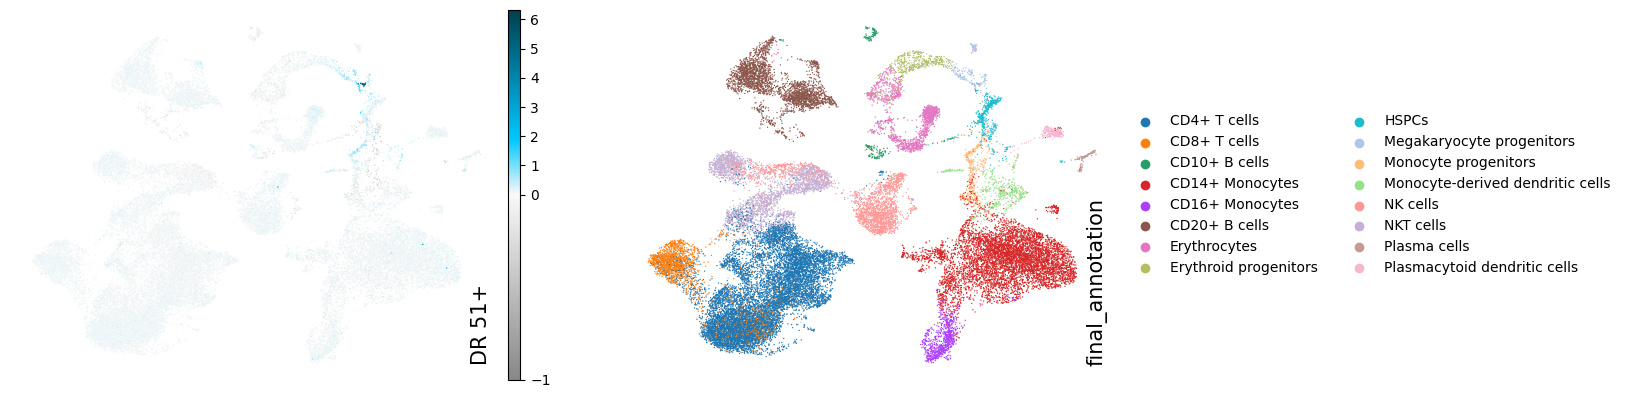

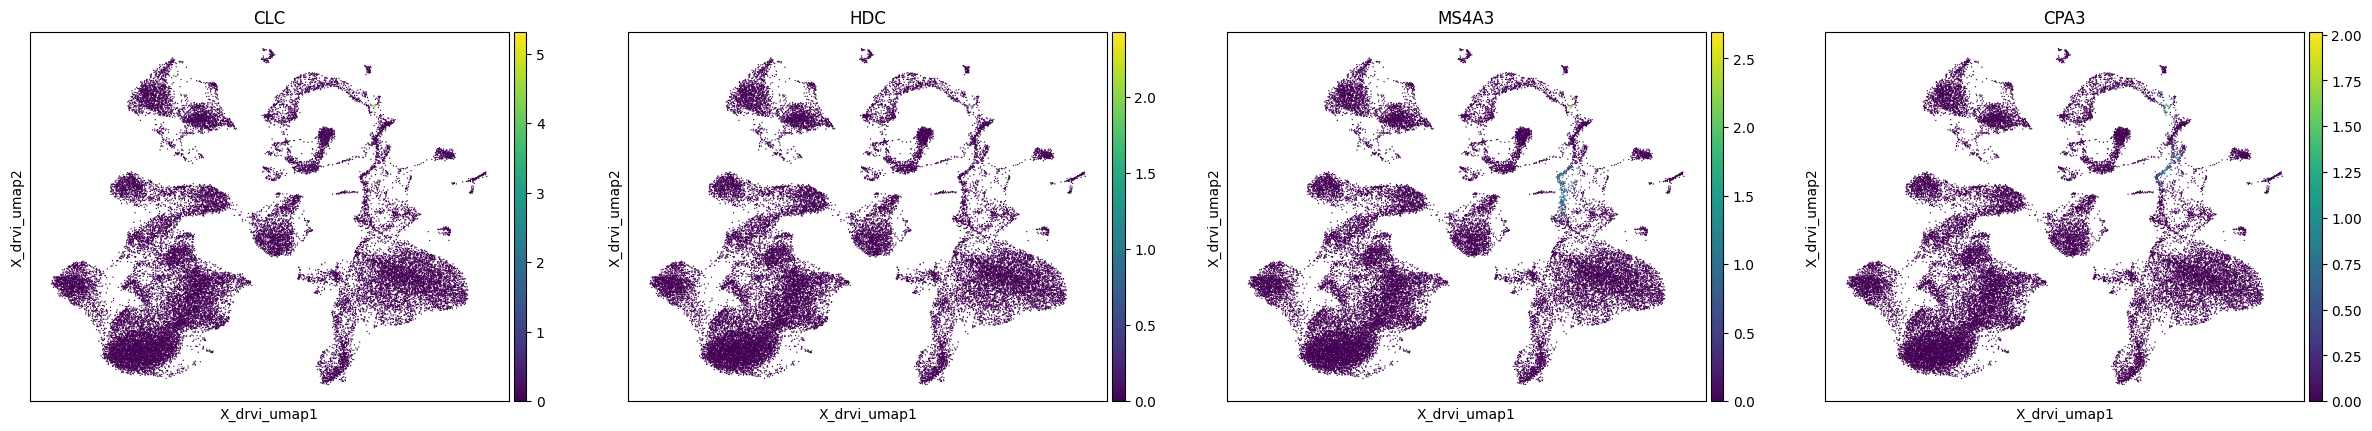

In [24]:
factor_label = "DR 51+"
inspect(factor_label, embed)
plot_factor_summary(factor_label, embed, adata, scores_df)

#### Inspect marker genes

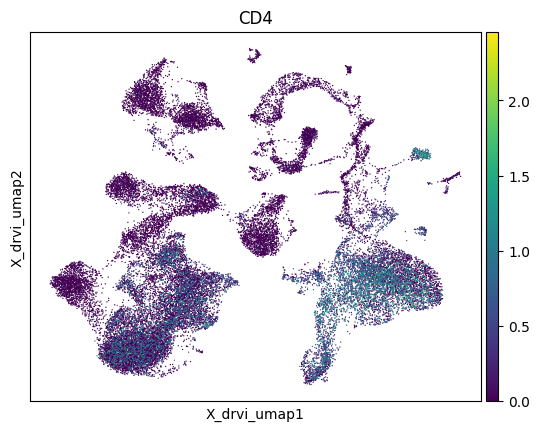

title
DR 14+    0.832676
DR 1-     0.289267
DR 56-    0.287836
DR 6-     0.214482
DR 19-    0.201490
DR 35+    0.166984
DR 21+    0.162839
DR 23-    0.136532
DR 13-    0.129817
DR 2-     0.107301
Name: CD4, dtype: float32

In [19]:
marker_gene = "CD4"
inspect_marker_gene(marker_gene, embed, adata)

### Record manual decisions

In [ ]:
MANUAL_LABELS = {
    # "DR 5+": "CD8 T cell effector",
}

### Write back to latent anndata

In [ ]:
for d, suf in [("+", "positive"), ("-", "negative")]:
    mapping = {k[:-1].strip(): v for k, v in MANUAL_LABELS.items() if k.endswith(d)}
    embed.var[f"{suf}_direction_manual_label"] = embed.var["title"].map(mapping)

ad.settings.allow_write_nullable_strings = True
embed.write_h5ad(embed_path)
print(f"Saved to: {embed_path}")

## 5. Appendix: Database reference

Swap the tool-specific config variables above (`process_blitzgsea_db`, `celltype_blitzgsea_dbs`, `gp_source`, `dc_geneset`, `gseapy_db`, `celltype_db`) to use different databases.

### Cell type marker databases (BlitzGSEA ORA only)

| Database | Description | BlitzGSEA name |
|----------|-------------|----------------|
| CellMarker 2.0 | Curated cell type markers from literature | `CellMarker_2024` |
| PanglaoDB | Curated markers from scRNA-seq studies | `PanglaoDB_Augmented_2021` |
| ARCHS4 Cell Lines | Gene expression signatures from cell lines | `ARCHS4_Cell-lines` |
| Tabula Muris | Cell type markers from single-cell mouse atlas | `Tabula_Muris` |
| Tabula Sapiens | Cell type markers from single-cell human atlas | `Tabula_Sapiens` |
| Human Gene Atlas | Tissue/cell type expression profiles | `Human_Gene_Atlas` |



### Biological process databases

| Database | Description | BlitzGSEA/GSEApy| g:Profiler | 
|----------|-------------|-------------------|------------|
| MSigDB Hallmark | 50 well curated non redundant biological states | `MSigDB_Hallmark_2020` | — |
| GO Biological Process | Comprehensive hierarchical processes | `GO_Biological_Process_2025` | `GO:BP` |
| GO Cellular Component | Subcellular localization | `GO_Cellular_Component_2025` | `GO:CC` |
| GO Molecular Function | Molecular activities | `GO_Molecular_Function_2025` | `GO:MF` |
| Reactome | Detailed, reaction-based pathways | `Reactome_Pathways_2024` | `REAC` |
| KEGG | Classic metabolic/signaling maps | `KEGG_2026` | `KEGG` | 
| WikiPathways | Community-curated biological maps | `WikiPathways_2024_Human` | `WP` |

### Regulatory networks (decoupler only)

| Network | Description | decoupler name | Notes|
|---------|-------------|---------------|---------|
| CollecTRI | TF → target gene regulons| `collectri` | Recommended for identifying TF drivers of a factor |
| PROGENy | Pathway-responsive genes signatures | `progeny` | Best for signaling (TGFb, MAPK, etc.) activity |
| DoRothEA |  TF → target gene interactions | `dorothea` |  Curated resource for Transcription Factor (TF) activity; uses confidence levels (A-D) |

### Clinical and Disease Phenotypes

| Database | Description | BlitzGSEA| g:Profiler |
|----------|-------------|-------------------|------------|
| Human Phenotype Ont. | Genes linked to clinical signs | Human_Phenotype_Ontology | HP |
| OMIM | Human genes and genetic disorders | OMIM_Disease | OMIM
